# lab2
#### Выполнил: Тропин Михаил М8О-311Б-23

[lЛаба2](https://drive.google.com/file/d/13QAv7JD7crDnPTlmscKnB6bVu9s1394Q/view)

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### Структура датасета
В датасете представлены следующие столбцы:

- ApplicationDate: Дата подачи заявки на кредит
- Age: Возраст заявителя
- AnnualIncome: Годовой доход
- CreditScore: Оценка кредитоспособности
- LoanAmount: Запрашиваемая сумма кредита
- LoanDuration: Срок погашения кредита
- MaritalStatus: Семейное положение заявителя
- NumberOfDependents: Количество иждивенцев
- HomeOwnershipStatus: Статус владения жильем
- MonthlyDebtPayments: Ежемесячные обязательства по долгам
- CreditCardUtilizationRate: Процент использования кредитной карты
- NumberOfOpenCreditLines: Активные кредитные линии
- NumberOfCreditInquiries: Количество запросов на кредит
- DebtToIncomeRatio: Соотношение долга к доходу
- BankruptcyHistory: История банкротств
- LoanPurpose: Цель кредита
- PreviousLoanDefaults: Предыдущие дефолты по кредитам
- PaymentHistory: История платежей
- LengthOfCreditHistory: Длительность кредитной истории
- SavingsAccountBalance: Баланс сберегательного счета
- CheckingAccountBalance: Баланс расчетного счета
- TotalAssets: Общая стоимость активов
- TotalLiabilities: Общая сумма обязательств
- MonthlyIncome: Ежемесячный доход
- UtilityBillsPaymentHistory: История платежей по коммунальным услугам
- JobTenure: Длительность работы на текущем месте
- EmploymentStatus: Статус занятости
- EducationLevel: Уровень образования
- Experience: Опыт работы
- NetWorth: Чистая стоимость активов
- BaseInterestRate: Базовая процентная ставка
- InterestRate: Применяемая процентная ставка
- MonthlyLoanPayment: Ежемесячный платеж по кредиту
- TotalDebtToIncomeRatio: Общее соотношение долга к доходу
- RiskScore: Оценка риска
- LoanApproved: Одобрен ли кредит

▎ Файлы
- train_c.csv - обучающая выборка
- test_c.csv - тестовая выборка
- ex_c.csv - пример файла для отправки в тестирующую систему

In [ ]:
try:
    train_df = pd.read_csv('train_c.csv')
    test_df = pd.read_csv('test_c.csv')
except FileNotFoundError:
    print("Ошибка: Файлы 'train_c.csv' или 'test_c.csv' не найдены.")

print('df info')
print(train_df.info())
print('test_df info')
print(test_df.info())
print('nulls cnt')
print(test_df.isna().sum().sum())
print('train_df example')
print(train_df.head())
print('LoanApproved example')
print(train_df["LoanApproved"])

df info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11017 entries, 0 to 11016
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ApplicationDate             10487 non-null  object 
 1   Age                         10487 non-null  float64
 2   AnnualIncome                10487 non-null  float64
 3   CreditScore                 9986 non-null   float64
 4   LoanAmount                  9986 non-null   float64
 5   LoanDuration                10487 non-null  float64
 6   MaritalStatus               10487 non-null  object 
 7   NumberOfDependents          10487 non-null  float64
 8   HomeOwnershipStatus         10487 non-null  object 
 9   MonthlyDebtPayments         9986 non-null   float64
 10  CreditCardUtilizationRate   10487 non-null  float64
 11  NumberOfOpenCreditLines     10487 non-null  float64
 12  NumberOfCreditInquiries     10487 non-null  float64
 13  DebtToIncomeRatio      

In [ ]:
print(train_df.describe())
print(test_df.describe())

                Age   AnnualIncome  CreditScore     LoanAmount  LoanDuration  \
count  10487.000000   10487.000000  9986.000000    9986.000000  10487.000000   
mean      39.850386  131587.872127   678.082716   29874.218306     53.439878   
std       11.614132  115791.941909   175.192486   27705.509722     24.493562   
min       18.000000   15000.000000   300.000000    1063.000000     12.000000   
25%       32.000000   20959.500000   550.000000   12658.000000     36.000000   
50%       40.000000   89015.000000   722.500000   21828.500000     48.000000   
75%       48.000000  257025.000000   850.000000   37158.000000     60.000000   
max       80.000000  748508.000000   850.000000  418997.000000    120.000000   

       NumberOfDependents  MonthlyDebtPayments  CreditCardUtilizationRate  \
count        10487.000000          9986.000000               10487.000000   
mean             1.568323           546.458642                   0.284397   
std              1.418684           501.981888  

In [ ]:
test_ids = test_df.get('ID', pd.Series(range(len(test_df)), name='ID'))

train_df.dropna(subset=['LoanApproved'], inplace=True)

y = train_df['LoanApproved']
columns_to_drop = ['LoanApproved', 'ID', 'ApplicationDate']

existing_cols_train = [col for col in columns_to_drop if col in train_df.columns]
X = train_df.drop(columns=existing_cols_train)

columns_to_drop_test = ['ID', 'ApplicationDate']
existing_cols_test = [col for col in columns_to_drop_test if col in test_df.columns]
X_test = test_df.drop(columns=existing_cols_test)

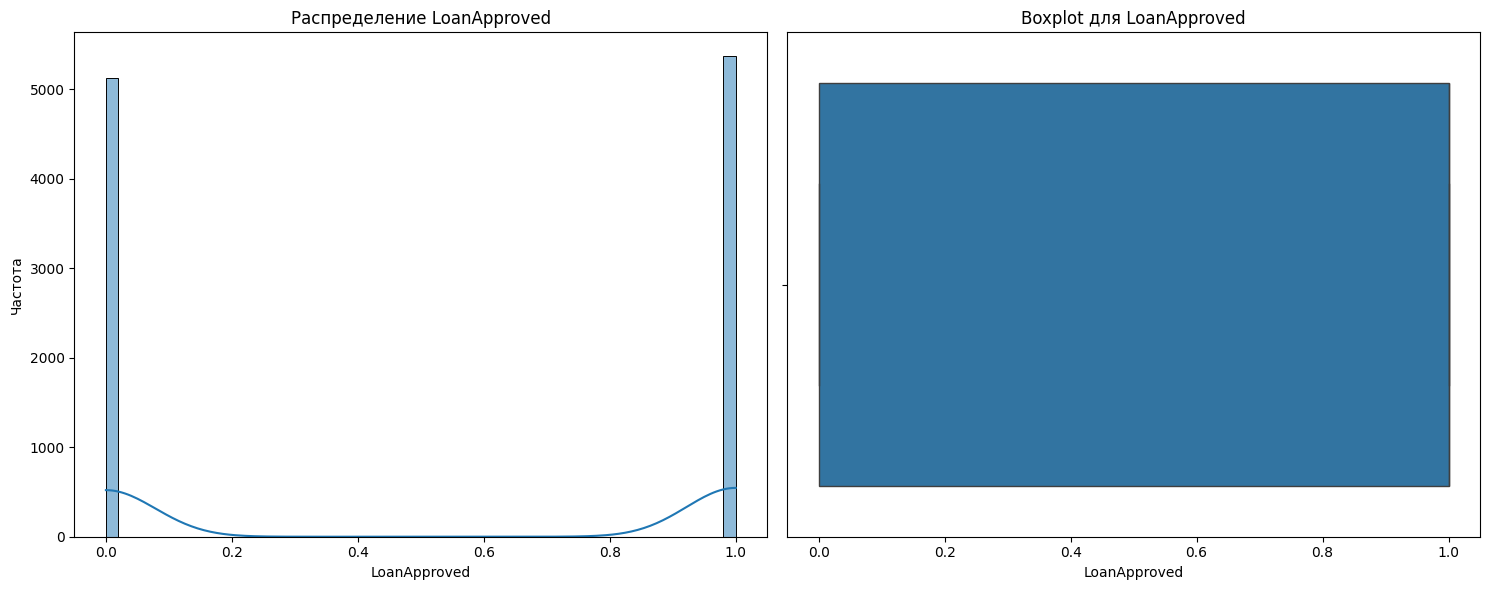

1% квантиль: 0.0 99% квантиль: 1.0


In [ ]:
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.histplot(y, kde=True, bins=50)
plt.title('Распределение LoanApproved')
plt.xlabel('LoanApproved')
plt.ylabel('Частота')

plt.subplot(1, 2, 2)
sns.boxplot(x=y)
plt.title('Boxplot для LoanApproved')
plt.xlabel('LoanApproved')

plt.tight_layout()
plt.show()

q_low, q_high = y.quantile([0.01, 0.99])
print("1% квантиль:", q_low, "99% квантиль:", q_high)

Числовые признаки: 28
Категориальные (число): 5

Категориальные признаки: ['MaritalStatus', 'HomeOwnershipStatus', 'LoanPurpose', 'EmploymentStatus', 'EducationLevel']


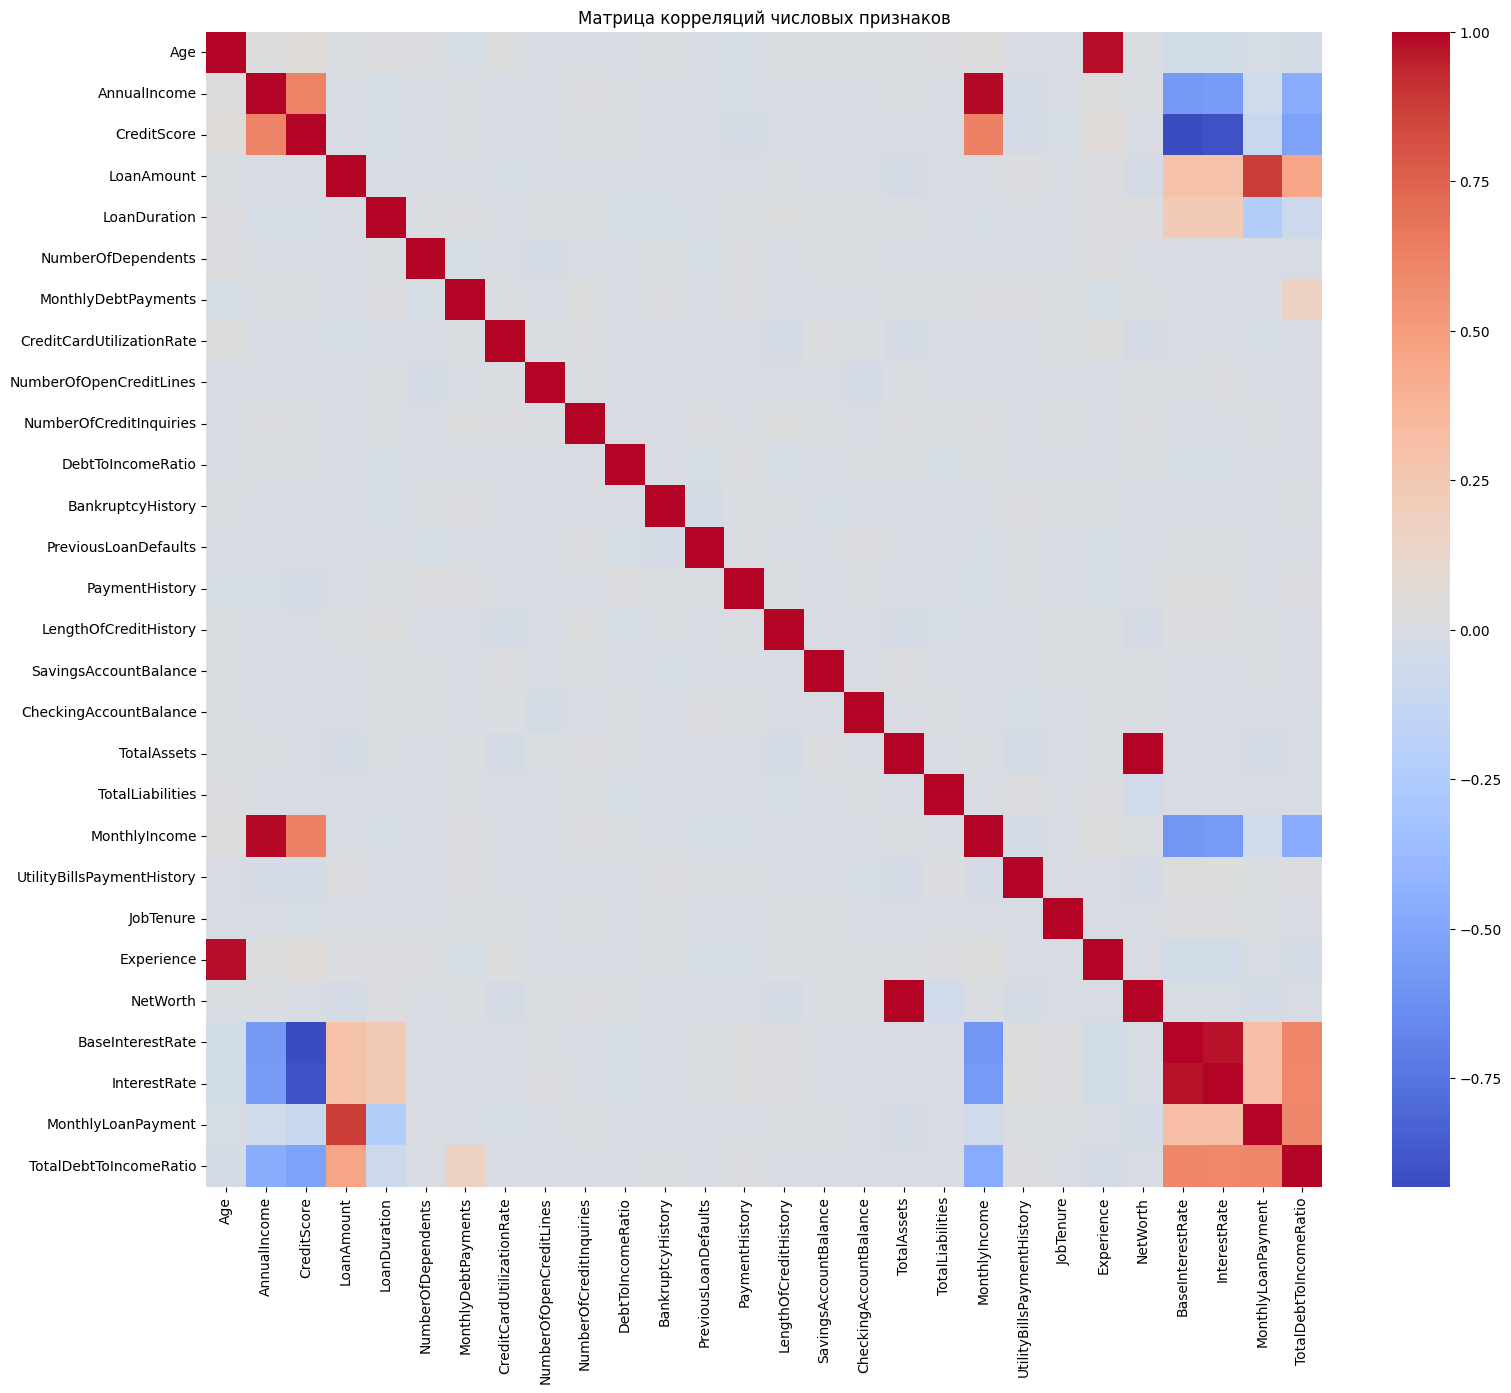

In [ ]:
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

print(f"Числовые признаки: {len(numeric_features)}")
print(f"Категориальные (число): {len(categorical_features)}")
print("\nКатегориальные признаки:", categorical_features)

plt.figure(figsize=(18, 15))
corr_mat = X[numeric_features].corr()
sns.heatmap(corr_mat, cmap='coolwarm', annot=False)
plt.title('Матрица корреляций числовых признаков')
plt.show()

15 коррелянтов:
Age                         NaN
AnnualIncome                NaN
CreditScore                 NaN
LoanAmount                  NaN
LoanDuration                NaN
NumberOfDependents          NaN
MonthlyDebtPayments         NaN
CreditCardUtilizationRate   NaN
NumberOfOpenCreditLines     NaN
NumberOfCreditInquiries     NaN
DebtToIncomeRatio           NaN
BankruptcyHistory           NaN
PreviousLoanDefaults        NaN
PaymentHistory              NaN
LengthOfCreditHistory       NaN
Name: LoanApproved, dtype: float64

15 некорелянтов:
PaymentHistory               NaN
LengthOfCreditHistory        NaN
SavingsAccountBalance        NaN
CheckingAccountBalance       NaN
TotalAssets                  NaN
TotalLiabilities             NaN
MonthlyIncome                NaN
UtilityBillsPaymentHistory   NaN
JobTenure                    NaN
Experience                   NaN
NetWorth                     NaN
BaseInterestRate             NaN
InterestRate                 NaN
MonthlyLoanPayment    

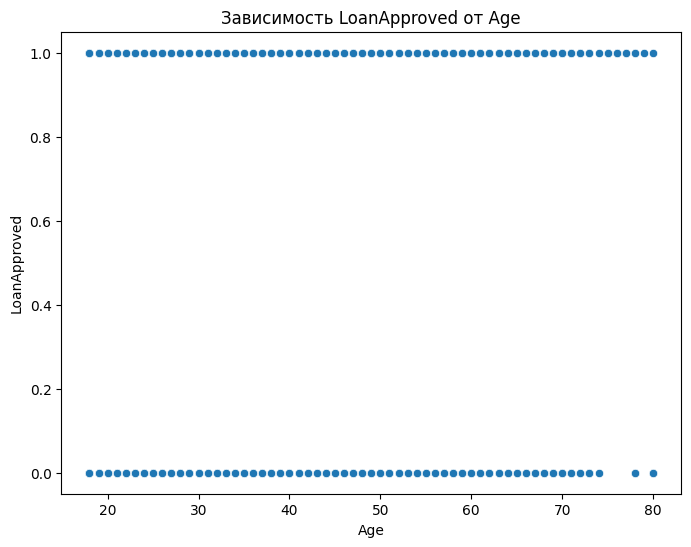

In [ ]:
corr_with_score = corr_mat.join(y.to_frame())['LoanApproved'].sort_values(ascending=False)

print("15 коррелянтов:")
print(corr_with_score.head(15))

print("\n15 некорелянтов:")
print(corr_with_score.tail(15))

most_correlated_feature = corr_with_score.index[0]

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X[most_correlated_feature], y=y)
plt.title(f'Зависимость LoanApproved от {most_correlated_feature}')
plt.xlabel(most_correlated_feature)
plt.ylabel('LoanApproved')
plt.show()

In [ ]:
print(f'Пропуски в df: {train_df.isna().sum().sum()}')
print(f'Пропуски в df_test: {test_df.isna().sum().sum()}')

Пропуски в df: 4509
Пропуски в df_test: 0


In [ ]:
for col in numeric_features:
    median_val = X[col].median()
    X[col] = X[col].fillna(median_val)
    X_test[col] = X_test[col].fillna(median_val)

for col in categorical_features:
    # mode_val = X[col].mode()[0]
    mode_values = X[col].mode()
    print(len(mode_values))
    middle_index = len(mode_values) // 2
    print(middle_index)
    mode_val = mode_values.iloc[middle_index] if len(mode_values) > 0 else "Other"
    print(mode_val)
    X[col] = X[col].fillna(mode_val)
    X_test[col] = X_test[col].fillna(mode_val)


1
0
Married
1
0
Mortgage
1
0
Home
1
0
Employed
1
0
High School


In [ ]:
print(f'Пропуски в df: {X.isna().sum().sum()}')
print(f'Пропуски в df_test: {X_test.isna().sum().sum()}')

Пропуски в df: 0
Пропуски в df_test: 0


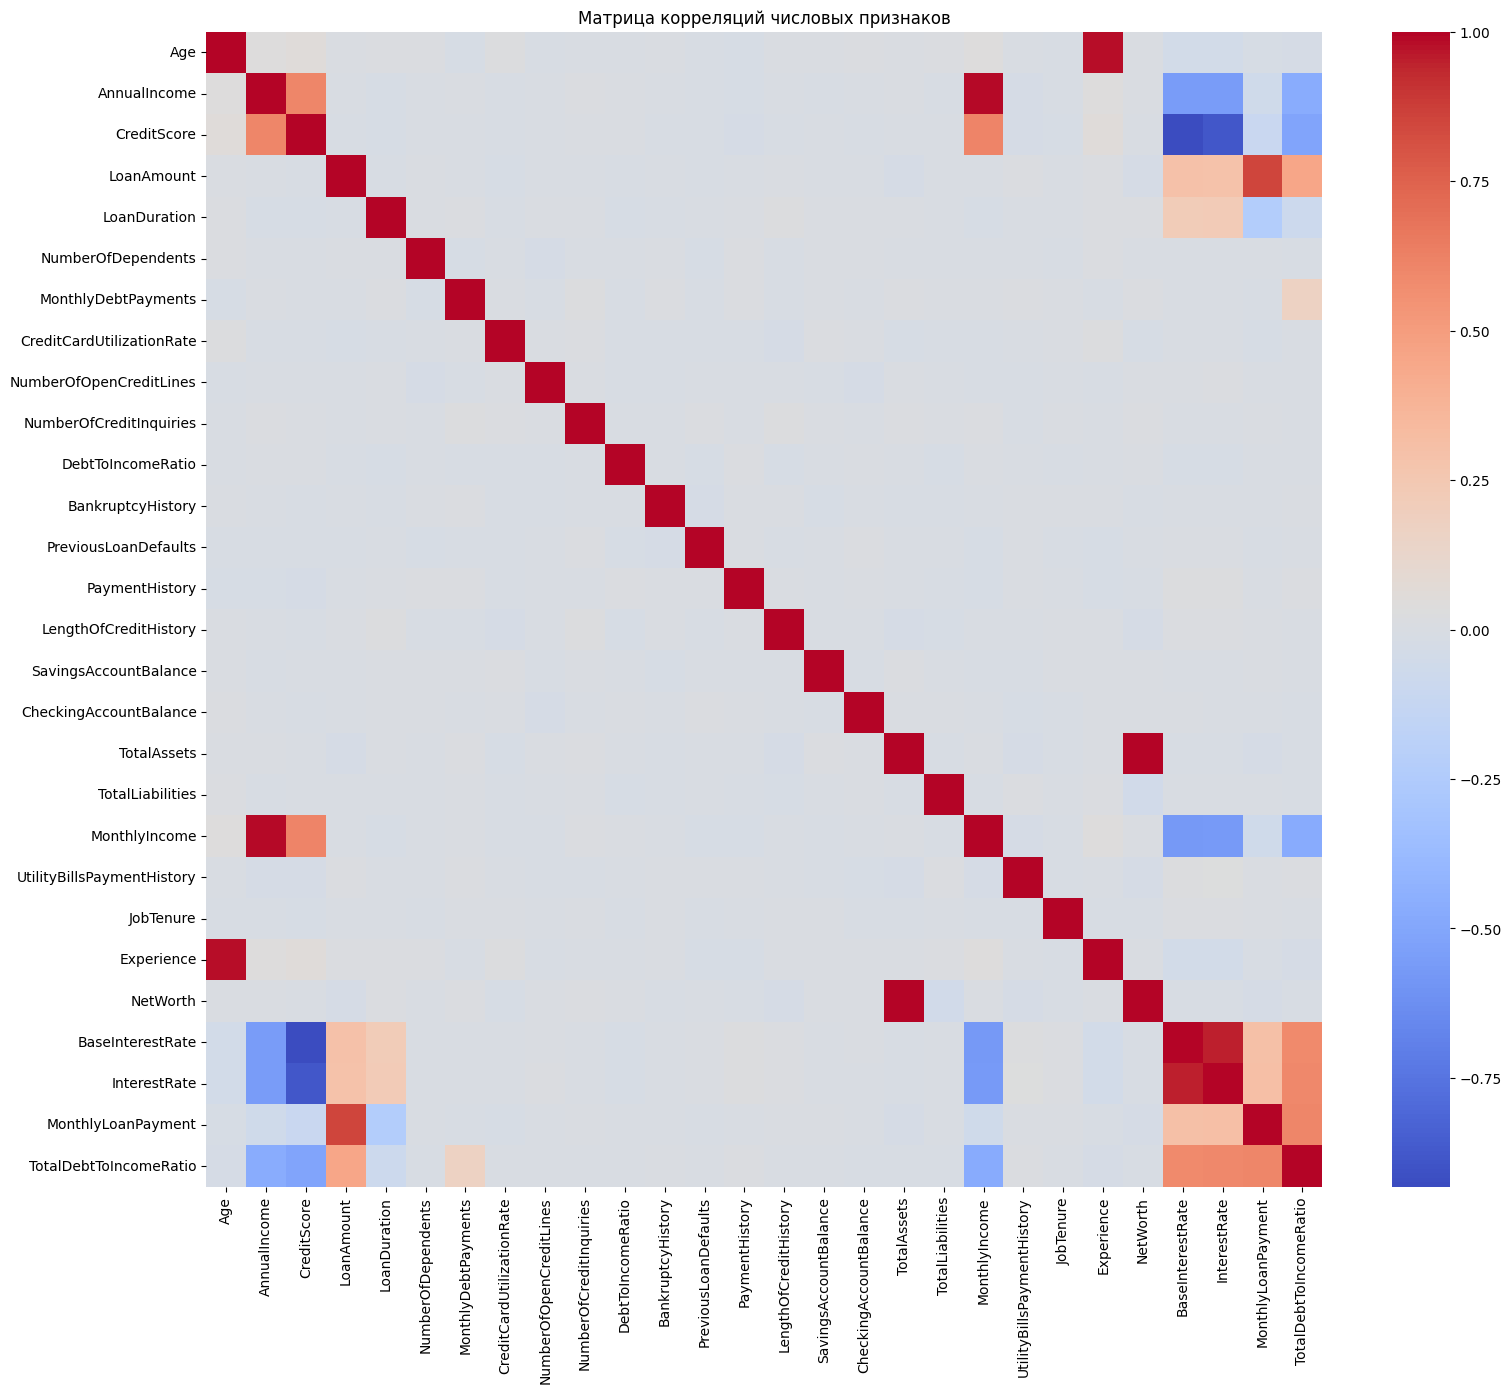

Топ-10 признаков, наиболее коррелирующих с LoanApproved:
MonthlyIncome              0.754853
AnnualIncome               0.743034
CreditScore                0.566592
NetWorth                   0.126548
TotalAssets                0.126146
LengthOfCreditHistory      0.038509
Experience                 0.036699
Age                        0.036580
DebtToIncomeRatio          0.014922
NumberOfCreditInquiries    0.012520
Name: LoanApproved, dtype: float64

Топ-10 признаков, наименее коррелирующих с LoanApproved:
UtilityBillsPaymentHistory   -0.020812
PreviousLoanDefaults         -0.029994
LoanDuration                 -0.039908
BankruptcyHistory            -0.040837
MonthlyDebtPayments          -0.042784
LoanAmount                   -0.190183
MonthlyLoanPayment           -0.217369
TotalDebtToIncomeRatio       -0.476222
BaseInterestRate             -0.589778
InterestRate                 -0.599180
Name: LoanApproved, dtype: float64


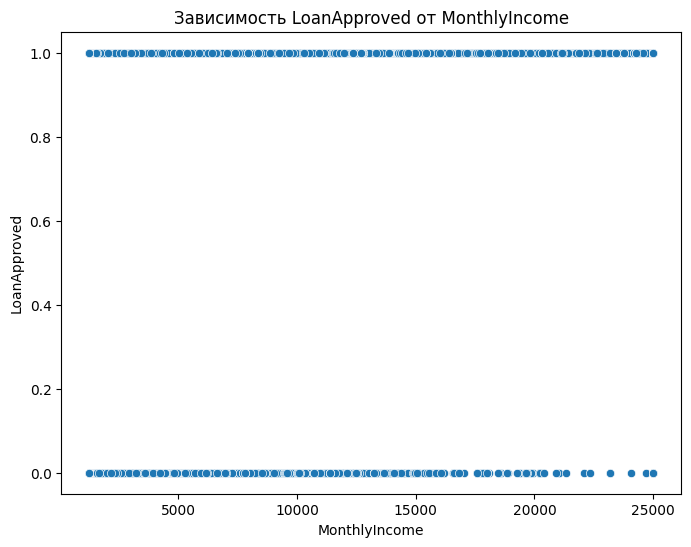

In [ ]:
plt.figure(figsize=(18, 15))
correlation_matrix = X[numeric_features].corr()
sns.heatmap(correlation_matrix, cmap='coolwarm')
plt.title('Матрица корреляций числовых признаков')
plt.show()

temp_df_numeric = X[numeric_features].join(y)

correlation_with_target = temp_df_numeric.corr()['LoanApproved'].sort_values(ascending=False)

print("Топ-10 признаков, наиболее коррелирующих с LoanApproved:")
print(correlation_with_target.head(11).drop('LoanApproved'))

print("\nТоп-10 признаков, наименее коррелирующих с LoanApproved:")
print(correlation_with_target.tail(10))

most_correlated_feature = correlation_with_target.index[1]

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X[most_correlated_feature], y=y)
plt.title(f'Зависимость LoanApproved от {most_correlated_feature}')
plt.xlabel(most_correlated_feature)
plt.ylabel('LoanApproved')
plt.show()

In [ ]:
# Удаление AnnualIncome
X_processed = train_df.copy()
X_test_processed = test_df.copy()
if 'AnnualIncome' in X_processed.columns:
    X_processed.drop(columns=['AnnualIncome'], inplace=True)
    X_test_processed.drop(columns=['AnnualIncome'], inplace=True)
    print("Столбец 'AnnualIncome' удален.")
y_raw = train_df['LoanApproved']
X = X_processed.drop(columns=['LoanApproved', 'ID', 'ApplicationDate'], errors='ignore')
X_test = X_test_processed.drop(columns=['ID', 'ApplicationDate'], errors='ignore')

Столбец 'AnnualIncome' удален.


In [ ]:
# Очистка выбросов в y
Q1 = y_raw.quantile(0.25)
Q3 = y_raw.quantile(0.75)
IQR = Q3 - Q1
k = 1.5
lower_bound = Q1 - k * IQR
upper_bound = Q3 + k * IQR
mask = (y_raw >= lower_bound) & (y_raw <= upper_bound)
y = y_raw[mask]
X = X[X.index.isin(y.index)]

In [ ]:
# Заполнение пропусков
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()
for col in numeric_features:
    median_val = X[col].median()
    X[col].fillna(median_val, inplace=True)
    X_test[col].fillna(median_val, inplace=True)
for col in categorical_features:
    mode_val = X[col].mode()[0]
    X[col].fillna(mode_val, inplace=True)
    X_test[col].fillna(mode_val, inplace=True)

/tmp/ipython-input-323244199.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X[col].fillna(median_val, inplace=True)
/tmp/ipython-input-323244199.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.met

In [ ]:
# Обработка выбросов в признаках
for col in numeric_features:
    lower_percentile = X[col].quantile(0.05)
    upper_percentile = X[col].quantile(0.95)
    X[col] = np.clip(X[col], lower_percentile, upper_percentile)
    X_test[col] = np.clip(X_test[col], lower_percentile, upper_percentile)


In [ ]:
# Некие смешные признаки
def create_ratios(df):
    epsilon = 1e-6
    if 'TotalLiabilities' in df.columns and 'TotalAssets' in df.columns:
        df['DebtToAssets_Ratio'] = df['TotalLiabilities'] / (df['TotalAssets'] + epsilon)
    if 'LoanAmount' in df.columns and 'MonthlyIncome' in df.columns:
        df['LoanToIncome_Ratio'] = df['LoanAmount'] / (df['MonthlyIncome'] + epsilon)
    if 'MonthlyLoanPayment' in df.columns and 'MonthlyIncome' in df.columns:
        df['PaymentToIncome_Ratio'] = df['MonthlyLoanPayment'] / (df['MonthlyIncome'] + epsilon)
    return df
X = create_ratios(X)
X_test = create_ratios(X_test)

In [ ]:
# кодируем категориальные признаки как чиселки

# EducationLevel
education_map = {'Doctorate': 0, 'Master': 1, 'Bachelor': 2, 'Associate': 3, 'High School': 4}
if 'EducationLevel' in X.columns:
    X["EducationLevel_num"] = X["EducationLevel"].map(education_map).fillna(2)
    X_test["EducationLevel_num"] = X_test["EducationLevel"].map(education_map).fillna(2)

# EmploymentStatus
employment_status_map = {"Employed": 0, "Self-Employed": 1, "Unemployed": 2}
if 'EmploymentStatus' in X.columns:
    X["EmploymentStatus_num"] = X["EmploymentStatus"].map(employment_status_map).fillna(1)
    X_test["EmploymentStatus_num"] = X_test["EmploymentStatus"].map(employment_status_map).fillna(1)

# MaritalStatus
marital_map = {'Married': 0, 'Single': 1, 'Divorced': 2, 'Widowed': 3}
if 'MaritalStatus' in X.columns:
    X["MaritalStatus_num"] = X["MaritalStatus"].map(marital_map).fillna(1.5)
    X_test["MaritalStatus_num"] = X_test["MaritalStatus"].map(marital_map).fillna(1.5)

# LoanPurpose
loan_purpose_map = {'Home': 0, 'Auto': 1, 'Education': 2, 'Debt Consolidation': 3, 'Other': 4}
if 'LoanPurpose' in X.columns:
    X['LoanPurpose_num'] = X['LoanPurpose'].map(loan_purpose_map).fillna(2)
    X_test['LoanPurpose_num'] = X_test['LoanPurpose'].map(loan_purpose_map).fillna(2)

# HomeOwnershipStatus
home_status_map = {"Own": 0, "Mortgage": 1, "Rent": 2, "Other": 3}
if 'HomeOwnershipStatus' in X.columns:
    X["HomeOwnershipStatus_num"] = X["HomeOwnershipStatus"].map(home_status_map).fillna(1.5)
    X_test["HomeOwnershipStatus_num"] = X_test["HomeOwnershipStatus"].map(home_status_map).fillna(1.5)

In [ ]:

from sklearn.preprocessing import PolynomialFeatures


# Бинарные признаки для частых значений MonthlyIncome
if 'MonthlyIncome' in X.columns:
    X['MonthlyIncome_Is1250'] = (X['MonthlyIncome'] == 1250).astype(int)
    X['MonthlyIncome_Is25000'] = (X['MonthlyIncome'] == 25000).astype(int)
    X_test['MonthlyIncome_Is1250'] = (X_test['MonthlyIncome'] == 1250).astype(int)
    X_test['MonthlyIncome_Is25000'] = (X_test['MonthlyIncome'] == 25000).astype(int)


# Бинарные признаки и трансформации CreditScore
if 'CreditScore' in X.columns:
    X['CreditScore_Is850'] = (X['CreditScore'] == 850).astype(int)
    X['CreditScore_Is300'] = (X['CreditScore'] == 300).astype(int)
    X_test['CreditScore_Is850'] = (X_test['CreditScore'] == 850).astype(int)
    X_test['CreditScore_Is300'] = (X_test['CreditScore'] == 300).astype(int)

    if 'CreditScore_Log' not in X.columns:
        X['CreditScore_Log'] = np.log1p(X['CreditScore'])
        X_test['CreditScore_Log'] = np.log1p(X_test['CreditScore'])
    if 'CreditScore_Sqrt' not in X.columns:
        X['CreditScore_Sqrt'] = np.sqrt(X['CreditScore'])
        X_test['CreditScore_Sqrt'] = np.sqrt(X_test['CreditScore'])
    if 'CreditScore_Cbrt' not in X.columns:
        X['CreditScore_Cbrt'] = np.cbrt(X['CreditScore'])
        X_test['CreditScore_Cbrt'] = np.cbrt(X_test['CreditScore'])


# Степенные признаки CreditScore
if 'CreditScore' in X.columns:
    if 'CreditScore_sq2' not in X.columns:
        X['CreditScore_sq2'] = X['CreditScore'] ** 2
        X_test['CreditScore_sq2'] = X_test['CreditScore'] ** 2
    if 'CreditScore_sq3' not in X.columns:
        X['CreditScore_sq3'] = X['CreditScore'] ** 3
        X_test['CreditScore_sq3'] = X_test['CreditScore'] ** 3


# Трансформации TotalDebtToIncomeRatio
if 'TotalDebtToIncomeRatio' in X.columns:
    if 'TotalDebtToIncomeRatio_sqrt3' not in X.columns:
        X["TotalDebtToIncomeRatio_sqrt3"] = np.cbrt(X['TotalDebtToIncomeRatio'])
        X_test['TotalDebtToIncomeRatio_sqrt3'] = np.cbrt(X_test['TotalDebtToIncomeRatio'])
    if 'TotalDebtToIncomeRatio_sqrt2' not in X.columns:
        X["TotalDebtToIncomeRatio_sqrt2"] = np.sqrt(X['TotalDebtToIncomeRatio'])
        X_test['TotalDebtToIncomeRatio_sqrt2'] = np.sqrt(X_test['TotalDebtToIncomeRatio'])
    if 'TotalDebtToIncomeRatio_log' not in X.columns:
        X["TotalDebtToIncomeRatio_log"] = np.log1p(X['TotalDebtToIncomeRatio'])
        X_test['TotalDebtToIncomeRatio_log'] = np.log1p(X_test['TotalDebtToIncomeRatio'])


# Взаимодействие CreditScore и TotalDebtToIncomeRatio
if 'CreditScore' in X.columns and 'TotalDebtToIncomeRatio' in X.columns:
    if 'CreditScore_TotalDebtToIncomeRatio' not in X.columns:
        X["CreditScore_TotalDebtToIncomeRatio"] = X["CreditScore"] * X["TotalDebtToIncomeRatio"]
        X_test["CreditScore_TotalDebtToIncomeRatio"] = X_test["CreditScore"] * X_test["TotalDebtToIncomeRatio"]

    if 'Log_CreditScore_TotalDebtToIncomeRatio' not in X.columns:
        X["Log_CreditScore_TotalDebtToIncomeRatio"] = np.log1p(X["CreditScore"]) * X["TotalDebtToIncomeRatio"]
        X_test["Log_CreditScore_TotalDebtToIncomeRatio"] = np.log1p(X_test["CreditScore"]) * X_test["TotalDebtToIncomeRatio"]


# Взаимодействие MonthlyIncome и LoanAmount
if 'MonthlyIncome' in X.columns and 'LoanAmount' in X.columns:
    if 'Income_LoanAmount_Interaction' not in X.columns:
        X["Income_LoanAmount_Interaction"] = X["MonthlyIncome"] * X["LoanAmount"]
        X_test["Income_LoanAmount_Interaction"] = X_test["MonthlyIncome"] * X_test["LoanAmount"]


# Взаимодействие TotalDebtToIncomeRatio и InterestRate
if 'TotalDebtToIncomeRatio' in X.columns and 'InterestRate' in X.columns:
    if 'Debt_Interest_Interaction' not in X.columns:
        X["Debt_Interest_Interaction"] = X["TotalDebtToIncomeRatio"] * X["InterestRate"]
        X_test["Debt_Interest_Interaction"] = X_test["TotalDebtToIncomeRatio"] * X_test["InterestRate"]


# Взаимодействие CreditScore и DTI (деление)
if 'CreditScore' in X.columns and 'TotalDebtToIncomeRatio' in X.columns:
    if 'CreditScore_DTI' not in X.columns:
        X['CreditScore_DTI'] = X['CreditScore'] / (X['TotalDebtToIncomeRatio'] + 1)
        X_test['CreditScore_DTI'] = X_test['CreditScore'] / (X_test['TotalDebtToIncomeRatio'] + 1)


# Взаимодействие BaseInterestRate и MonthlyIncome
if 'BaseInterestRate' in X.columns and 'MonthlyIncome' in X.columns:
    if 'BaseInterestRate_MonthlyIncome' not in X.columns:
        X["BaseInterestRate_MonthlyIncome"] = X['MonthlyIncome'] * X["BaseInterestRate"]
        X_test["BaseInterestRate_MonthlyIncome"] = X_test['MonthlyIncome'] * X_test["BaseInterestRate"]


# Логарифмические трансформации ключевых признаков
features_for_log = ["MonthlyLoanPayment", "LoanAmount", "NetWorth", "TotalAssets"]
for feature in features_for_log:
    if feature in X.columns and f'Log_{feature}' not in X.columns:
        X[f'Log_{feature}'] = np.log1p(X[feature])
        X_test[f'Log_{feature}'] = np.log1p(X_test[feature])


# Биннинг ключевых признаков
numeric_for_binning = [col for col in X.select_dtypes(include=np.number).columns
                       if not (col.startswith(('MonthlyIncome_Is', 'CreditScore_Is', 'Log_')) or
                               col.endswith(('_sqrt3', '_sqrt2', '_log', '_sq2', '_sq3', '_Cbrt', '_Sqrt', '_Log')) or
                               'Interaction' in col or '_Ratio' in col)]

features_to_bin = ['Age', 'CreditScore', 'LengthOfCreditHistory', 'LoanAmount', 'MonthlyIncome']
features_to_bin = [col for col in features_to_bin if col in X.columns and col in numeric_for_binning]

Q_BINS = 8
for col in features_to_bin:
    if col in X.columns:
        X[f'{col}_bin'] = pd.qcut(X[col], q=Q_BINS, labels=False, duplicates='drop').astype('category')
        X_test[f'{col}_bin'] = pd.qcut(X_test[col], q=Q_BINS, labels=False, duplicates='drop').astype('category')


# Полиномиальные признаки - то есть он берет фичу a и b и делает из них  [1, a, b, a^2, ab, b^2]
exclude_patterns = ['_bin', '_Is', '_Log', '_Sqrt', '_Cbrt', '_sq2', '_sq3',
                    '_sqrt2', '_sqrt3', '_log', 'Interaction', '_Ratio', '_num']

original_numeric_features = [col for col in X.select_dtypes(include=np.number).columns.tolist()
                             if not any(pattern in col for pattern in exclude_patterns)]

poly = PolynomialFeatures(degree=2, include_bias=False, interaction_only=True)

poly_features_train = poly.fit_transform(X[original_numeric_features])
poly_df_train = pd.DataFrame(
    poly_features_train,
    columns=poly.get_feature_names_out(original_numeric_features),
    index=X.index
)

poly_features_test = poly.transform(X_test[original_numeric_features])
poly_df_test = pd.DataFrame(
    poly_features_test,
    columns=poly.get_feature_names_out(original_numeric_features),
    index=X_test.index
)

# Определяем типы признаков
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()
new_numeric_features = [col for col in X.select_dtypes(include=np.number).columns
                        if col not in original_numeric_features and col not in categorical_features]

# Объединяем полиномиальные, категориальные и новые числовые признаки
X = pd.concat([
    X[categorical_features],
    poly_df_train,
    X[new_numeric_features]
], axis=1)

X_test = pd.concat([
    X_test[categorical_features],
    poly_df_test,
    X_test[new_numeric_features]
], axis=1)


# Объединяем редкие категории
all_categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

for col in all_categorical_features:
    X[col] = X[col].astype('category')
    X_test[col] = X_test[col].astype('category')

for col in all_categorical_features:
    value_counts = X[col].value_counts(normalize=True)
    rare_cats = value_counts[value_counts < 0.01].index.tolist()

    if rare_cats:
        if 'Other' not in X[col].cat.categories:
            X[col] = X[col].cat.add_categories('Other')
            X_test[col] = X_test[col].cat.add_categories('Other')

        X[col] = X[col].replace(rare_cats, 'Other')
        X_test[col] = X_test[col].replace(rare_cats, 'Other')


X = pd.get_dummies(X, columns=categorical_features, drop_first=True)
X_test = pd.get_dummies(X_test, columns=categorical_features, drop_first=True)


# выравнивание столбиков
train_cols = X.columns
test_cols = X_test.columns
missing_in_test = set(train_cols) - set(test_cols)
for c in missing_in_test:
    X_test[c] = 0
X_test = X_test[train_cols]

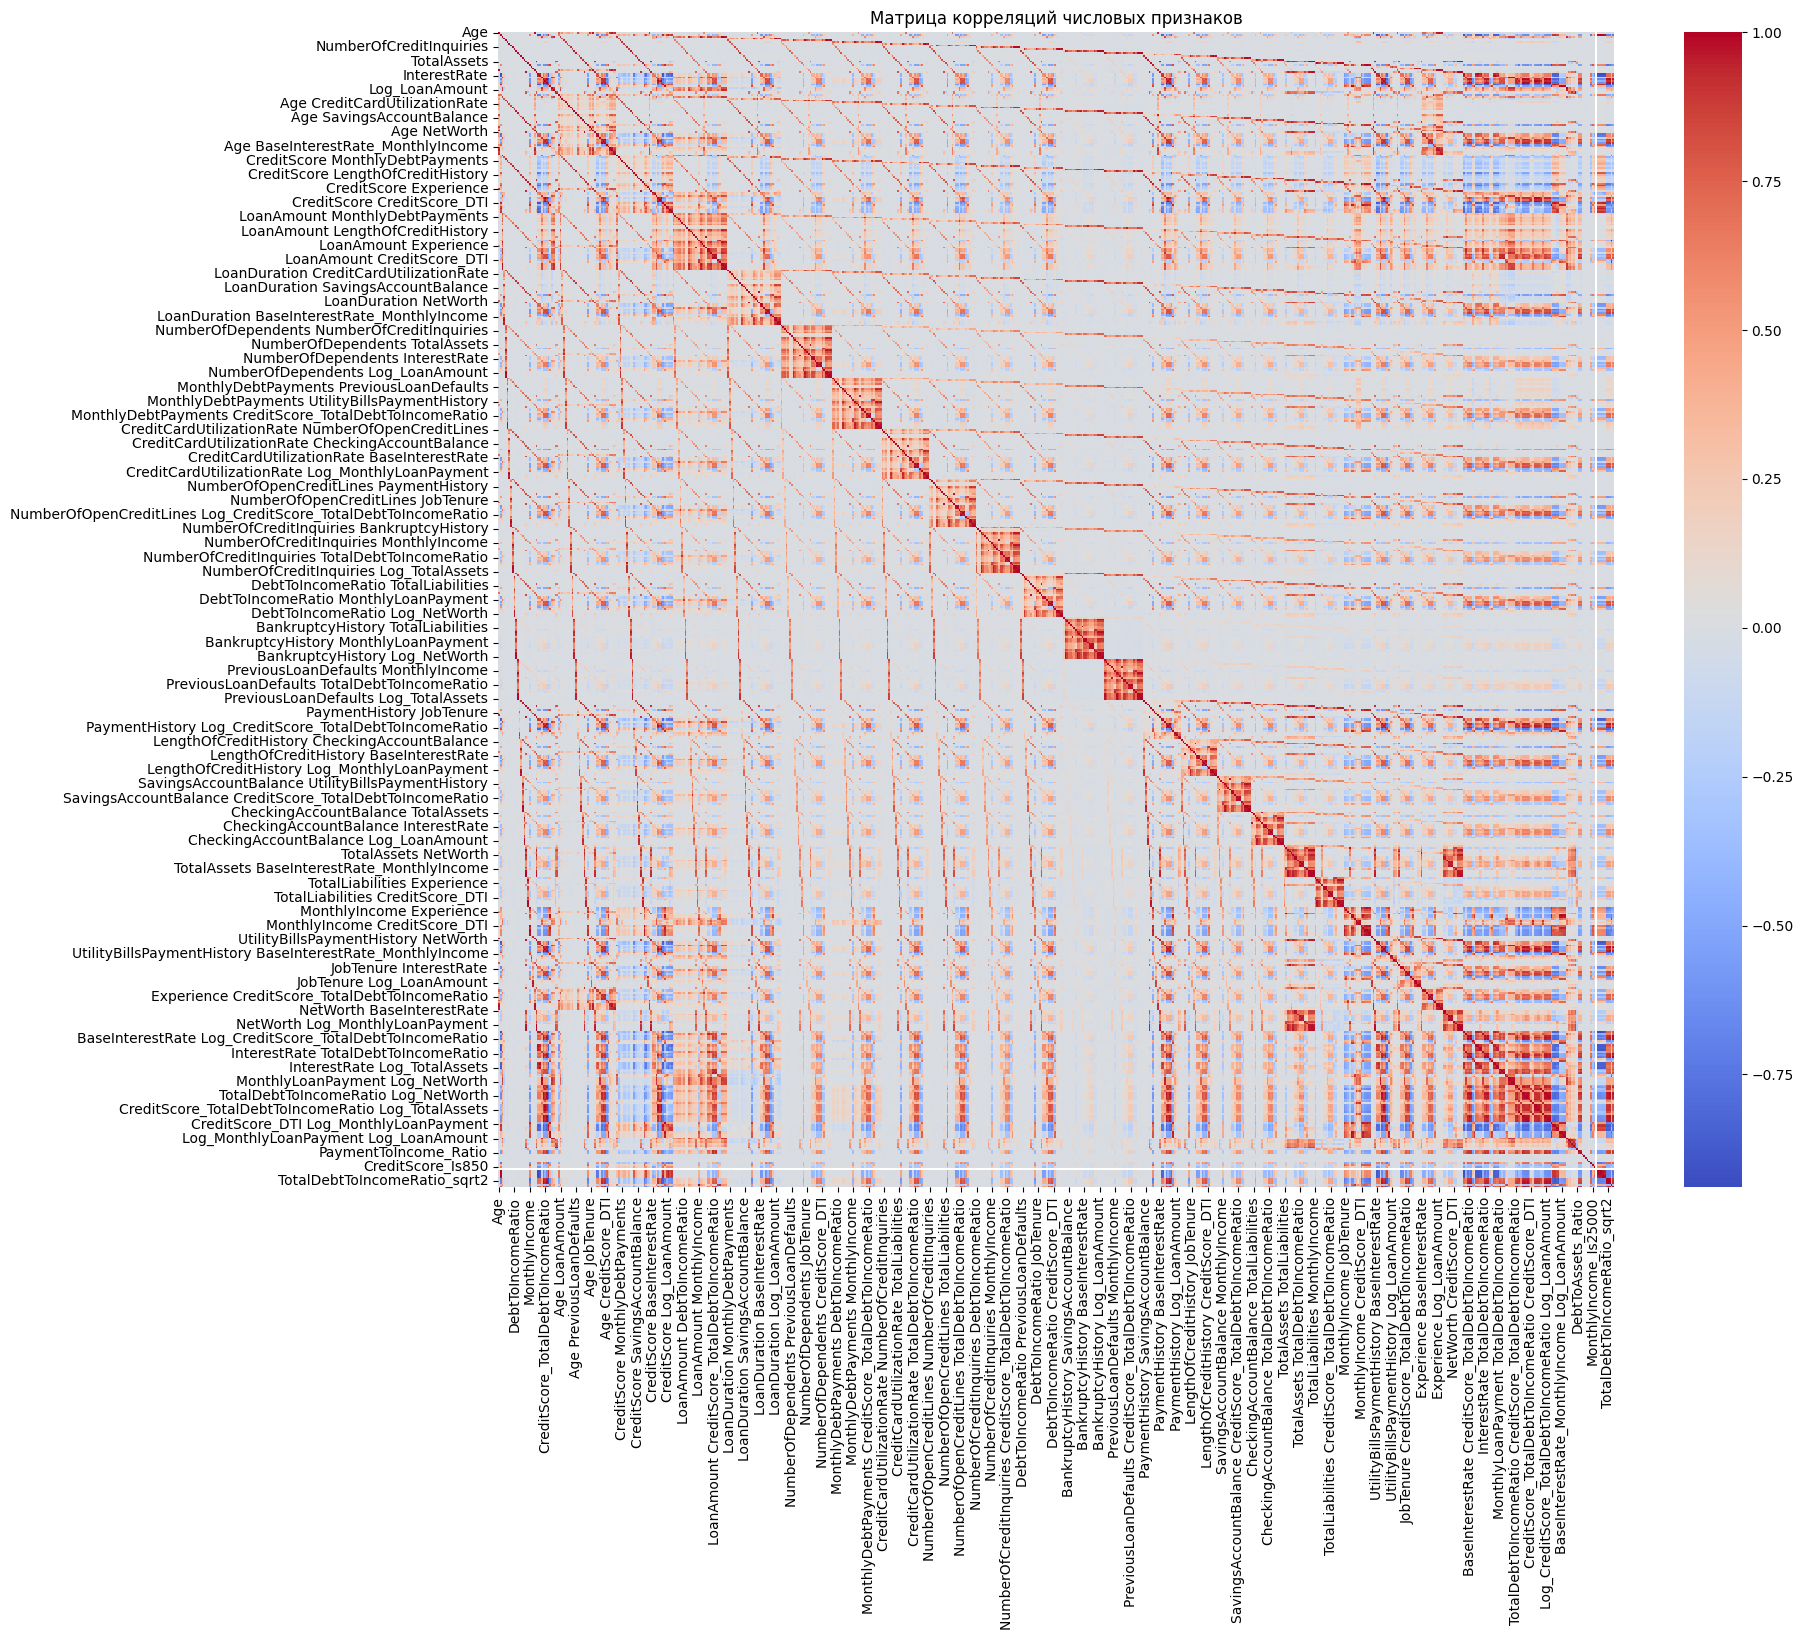

MonthlyIncome                               0.754853
MonthlyIncome CreditScore_DTI               0.754187
MonthlyIncome Log_TotalAssets               0.751546
CreditScore MonthlyIncome                   0.746076
MonthlyIncome Log_NetWorth                  0.744457
CreditScore_DTI                             0.742221
MonthlyIncome Log_LoanAmount                0.737416
CreditScore_DTI Log_TotalAssets             0.736481
MonthlyIncome UtilityBillsPaymentHistory    0.736201
PaymentHistory MonthlyIncome                0.725434
Name: LoanApproved, dtype: float64
CreditScore TotalDebtToIncomeRatio                                  -0.628658
UtilityBillsPaymentHistory Log_CreditScore_TotalDebtToIncomeRatio   -0.630630
TotalDebtToIncomeRatio                                              -0.636281
Log_CreditScore_TotalDebtToIncomeRatio                              -0.641652
Log_CreditScore_TotalDebtToIncomeRatio CreditScore_DTI              -0.682688
TotalDebtToIncomeRatio_log                   

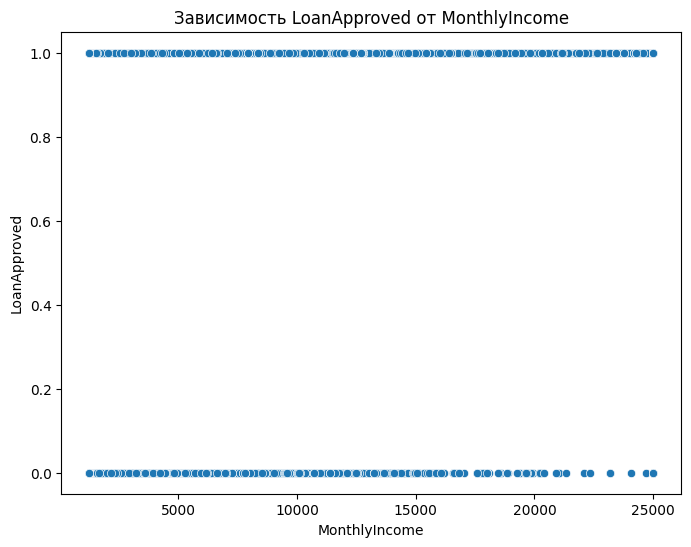

In [ ]:
plt.figure(figsize=(18, 15))
corr_mat = X.select_dtypes(include=['number']).corr()
sns.heatmap(corr_mat, cmap='coolwarm')
plt.title('Матрица корреляций числовых признаков')
plt.show()

tmp_df = X.select_dtypes(include=['number']).join(y)

corr_with_target = tmp_df.corr()['LoanApproved'].sort_values(ascending=False)

print(corr_with_target.head(11).drop('LoanApproved'))
print("============")
print(corr_with_target.tail(10))

most_correlated_feature = corr_with_target.index[1]

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X[most_correlated_feature], y=y)
plt.title(f'Зависимость LoanApproved от {most_correlated_feature}')
plt.xlabel(most_correlated_feature)
plt.ylabel('LoanApproved')
plt.show()

In [ ]:
def z_score_scaler_fit(data):
    mean = np.mean(data, axis=0)
    std = np.std(data, axis=0)
    std[std == 0] = 1
    return mean, std

def z_score_scaler_transform(data, mean, std):
    return (data - mean) / std

def min_max_scaler_fit(data):
    min_val = np.min(data, axis=0)
    max_val = np.max(data, axis=0)
    scale = max_val - min_val
    scale[scale == 0] = 1
    return min_val, scale

def min_max_scaler_transform(data, min_val, scale):
    return (data - min_val) / scale


X_np = X.astype(float).values
y_np = y.values
X_test_np = X_test.astype(float).values

mean_z, std_z = z_score_scaler_fit(X_np)
X_scaled = z_score_scaler_transform(X_np, mean_z, std_z)
X_test_scaled = z_score_scaler_transform(X_test_np, mean_z, std_z)

min_mm, scale_mm = min_max_scaler_fit(X_np)
X_mm_scaled = min_max_scaler_transform(X_np, min_mm, scale_mm)

In [ ]:
!pip install xgboost catboost lightgbm --break-system-packages

In [ ]:
import numpy as np
from sklearn.base import clone
import pandas as pd
from scipy.stats import mode

class Bagging:
    def __init__(self, base_estimator, n_estimators=10, random_state=None):
        self.base_estimator = base_estimator
        self.n_estimators = n_estimators
        self.random_state = random_state
        self.estimators_ = []
        self.estimators_samples_ = []
        if random_state is not None:
            np.random.seed(random_state)

    def _preprocess_data(self, X, y):
        X_processed = X.copy()
        y_processed = y.copy()
        for col in X_processed.columns:
            if X_processed[col].dtype == 'object':
                if set(X_processed[col].dropna().unique()) <= {'True', 'False', 'true', 'false', 'TRUE', 'FALSE'}:
                    X_processed[col] = X_processed[col].map({'True': 1, 'true': 1, 'TRUE': 1,
                                                            'False': 0, 'false': 0, 'FALSE': 0})
                else:
                    from sklearn.preprocessing import LabelEncoder
                    le = LabelEncoder()
                    X_processed[col] = le.fit_transform(X_processed[col].astype(str).fillna('missing'))
        if y_processed.dtype == 'object':
            if set(y_processed.dropna().unique()) <= {'True', 'False', 'true', 'false', 'TRUE', 'FALSE'}:
                y_processed = y_processed.map({'True': 1, 'true': 1, 'TRUE': 1,
                                              'False': 0, 'false': 0, 'FALSE': 0})
        return X_processed, y_processed

    def fit(self, X, y):
        self.estimators_ = []
        self.estimators_samples_ = []
        X_processed, y_processed = self._preprocess_data(X, y)
        self.feature_columns_ = X.columns.tolist()
        n_samples = X_processed.shape[0]
        for i in range(self.n_estimators):
            indices = np.random.choice(n_samples, n_samples, replace=True)
            X_sample = X_processed.iloc[indices] if isinstance(X_processed, pd.DataFrame) else X_processed[indices]
            y_sample = y_processed.iloc[indices] if isinstance(y_processed, pd.Series) else y_processed[indices]
            estimator = clone(self.base_estimator)
            estimator.fit(X_sample, y_sample)
            self.estimators_.append(estimator)
            self.estimators_samples_.append(indices)
        return self

    def predict(self, X):
        X_processed = X.copy()
        for col in X_processed.columns:
            if col in self.feature_columns_ and X_processed[col].dtype == 'object':
                if set(X_processed[col].dropna().unique()) <= {'True', 'False', 'true', 'false', 'TRUE', 'FALSE'}:
                    X_processed[col] = X_processed[col].map({'True': 1, 'true': 1, 'TRUE': 1,
                                                            'False': 0, 'false': 0, 'FALSE': 0})
        all_predictions = []
        for estimator in self.estimators_:
            pred = estimator.predict(X_processed)
            all_predictions.append(pred)
        preds_array = np.array(all_predictions)
        majority_preds, _ = mode(preds_array, axis=0, keepdims=False)
        return majority_preds.flatten()

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

X_val, X_test_final, y_val, y_test_final = train_test_split(
    X_test, y_test, test_size=0.5, random_state=42
)

X_train_processed = X_train.copy()
X_val_processed = X_test.copy()
X_test_processed = X_test.copy()

y_train_processed = y_train.copy()
if y_train_processed.dtype == 'object':
    y_train_processed = y_train_processed.map({'True': 1, 'true': 1, 'TRUE': 1,
                                               'False': 0, 'false': 0, 'FALSE': 0})

y_val_processed = y_test.copy()
if y_val_processed.dtype == 'object':
    y_val_processed = y_val_processed.map({'True': 1, 'true': 1, 'TRUE': 1,
                                          'False': 0, 'false': 0, 'FALSE': 0})

print("\nMy Bagging...")

X_train_processed = pd.DataFrame(X_train_processed)
X_val_processed = pd.DataFrame(X_val_processed)

bag = Bagging(DecisionTreeClassifier(), n_estimators=10, random_state=42)
bag.fit(X_train_processed, y_train_processed)

y_pred_my = bag.predict(X_val_processed)
acc_my = accuracy_score(y_val_processed, y_pred_my)
rocauc_my = roc_auc_score(y_val_processed, y_pred_my)
print(f"Bagging accuracy: {acc_my:.4f}")
print(f"Bagging roc_auc: {rocauc_my:.4f}")

print("\nsklearn Bagging...")
sk_bag = BaggingClassifier(
    DecisionTreeClassifier(),
    n_estimators=10,
    random_state=42,
    bootstrap=True
)
sk_bag.fit(X_train_processed, y_train_processed)

y_pred_sk = sk_bag.predict(X_val_processed)
acc_sk = accuracy_score(y_val_processed, y_pred_sk)
rocauc_sk = roc_auc_score(y_val_processed, y_pred_sk)
print(f"Bagging (sklearn) accuracy: {acc_sk:.4f}")
print(f"Bagging (sklearn) roc_auc: {rocauc_sk:.4f}")

X_train_split type: <class 'pandas.core.frame.DataFrame'>
X_train_split shape: (7340, 699)
y_train_split type: <class 'pandas.core.series.Series'>

Preprocessing data...

My Bagging...
Bagging accuracy: 0.9139
Bagging roc_auc: 0.9140

sklearn Bagging...
Bagging (sklearn) accuracy: 0.9085
Bagging (sklearn) roc_auc: 0.9087


ГРАДИЕНТНЫЙ БУСТИНГ: РЕАЛИЗАЦИЯ И СРАВНЕНИЕ
СРАВНЕНИЕ ГРАДИЕНТНОГО БУСТИНГА ДЛЯ КЛАССИФИКАЦИИ

a) Наша реализация (MyGradientBoostingClassifier):
   Accuracy: 0.8900
   AUC-ROC: 0.9559
   Количество деревьев: 100

b) Sklearn GradientBoostingClassifier:
   Accuracy: 0.9083
   AUC-ROC: 0.9655

c) XGBoost:
   Accuracy: 0.9100
   AUC-ROC: 0.9700

d) LightGBM:


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


   Accuracy: 0.9183
   AUC-ROC: 0.9692

e) CatBoost:
   Accuracy: 0.9200
   AUC-ROC: 0.9709

СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ

Модель                | Accuracy  | AUC-ROC   | Отличие от лучшей
-----------------------------------------------------------------
Наша реализация      | 0.8900    | 0.9559    | Acc: 0.0300, AUC: 0.0150
Sklearn              | 0.9083    | 0.9655    | Acc: 0.0117, AUC: 0.0054
XGBoost              | 0.9100    | 0.9700    | Acc: 0.0100, AUC: 0.0009
LightGBM             | 0.9183    | 0.9692    | Acc: 0.0017, AUC: 0.0017
CatBoost             | 0.9200    | 0.9709    | Acc: 0.0000, AUC: 0.0000

АНАЛИЗ СХОДИМОСТИ НАШЕЙ РЕАЛИЗАЦИИ
n_estimators= 10: Train Acc=0.9113, Test Acc=0.9350, Train AUC=0.9616, Test AUC=0.9716
n_estimators= 50: Train Acc=0.9287, Test Acc=0.9150, Train AUC=0.9753, Test AUC=0.9799
n_estimators=100: Train Acc=0.9463, Test Acc=0.9400, Train AUC=0.9843, Test AUC=0.9829
n_estimators=200: Train Acc=0.9575, Test Acc=0.9400, Train AUC=0.9921, Test AUC=0.9852
n_

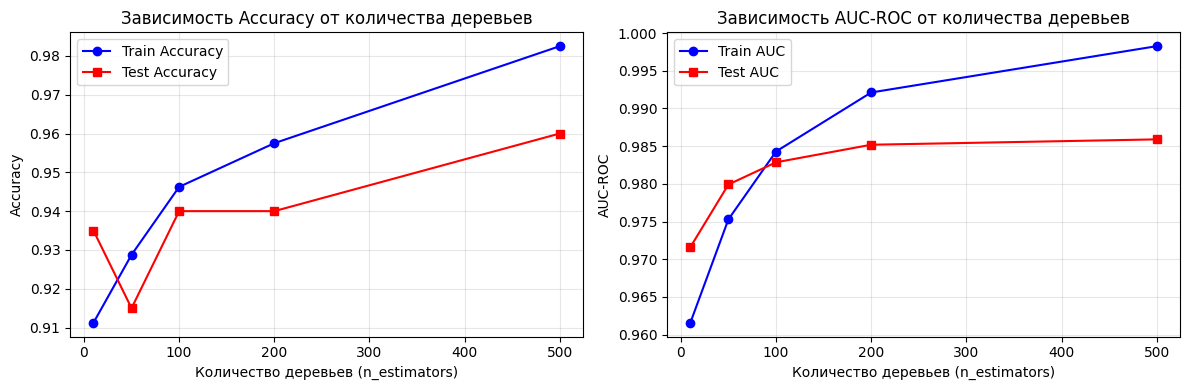


ВЛИЯНИЕ LEARNING RATE НА СХОДИМОСТЬ
Learning Rate 0.001: Final Test Accuracy = 0.8550
Learning Rate 0.010: Final Test Accuracy = 0.8800
Learning Rate 0.100: Final Test Accuracy = 0.8900
Learning Rate 0.300: Final Test Accuracy = 0.8950
Learning Rate 0.500: Final Test Accuracy = 0.8900
Learning Rate 1.000: Final Test Accuracy = 0.8850


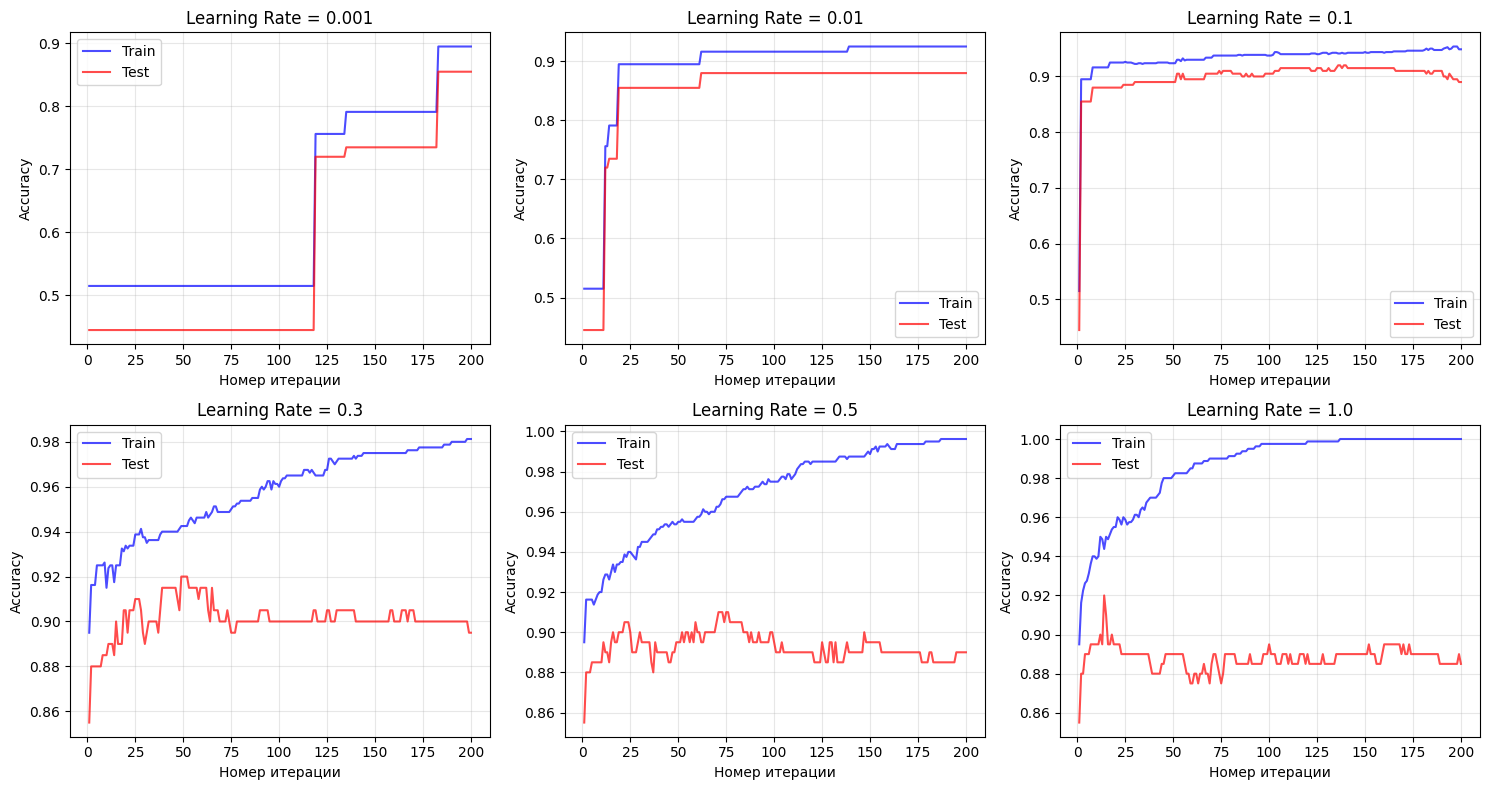


СРАВНЕНИЕ ВАЖНОСТИ ПРИЗНАКОВ


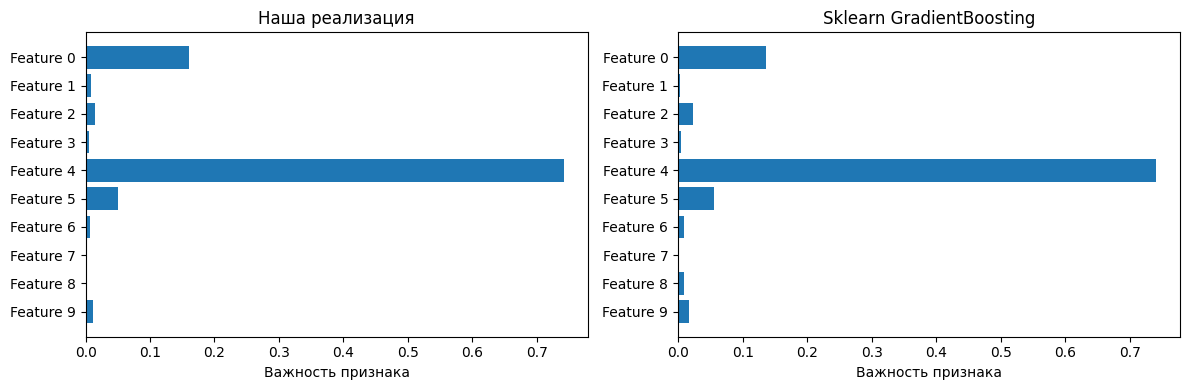


Корреляция важностей признаков между реализациями:
Коэффициент корреляции Пирсона: 0.9992

Топ-3 признака по важности:
Наша реализация:
  1. Feature 4: 0.7417
  2. Feature 0: 0.1611
  3. Feature 5: 0.0500

Sklearn:
  1. Feature 4: 0.7407
  2. Feature 0: 0.1367
  3. Feature 5: 0.0560

ПРАКТИЧЕСКИЕ РЕКОМЕНДАЦИИ

    ОСНОВНЫЕ ВЫВОДЫ:

    1. НАША РЕАЛИЗАЦИЯ:
       - Правильно реализует основные принципы градиентного бустинга
       - Достигает сравнимых результатов с sklearn на простых задачах
       - Легче для понимания и модификации

    2. ПРОИЗВОДИТЕЛЬНОСТЬ:
       - Наша реализация медленнее из-за использования обычных деревьев
       - Библиотеки (XGBoost, LightGBM) используют оптимизированные алгоритмы

    3. КАЧЕСТВО:
       - На простых задачах разница минимальна
       - На сложных задачах промышленные библиотеки показывают лучшее качество
       - Наша реализация может переобучаться при неправильных параметрах

    4. ПРАКТИЧЕСКИЕ СОВЕТЫ:

    a) Для образовательных целей:


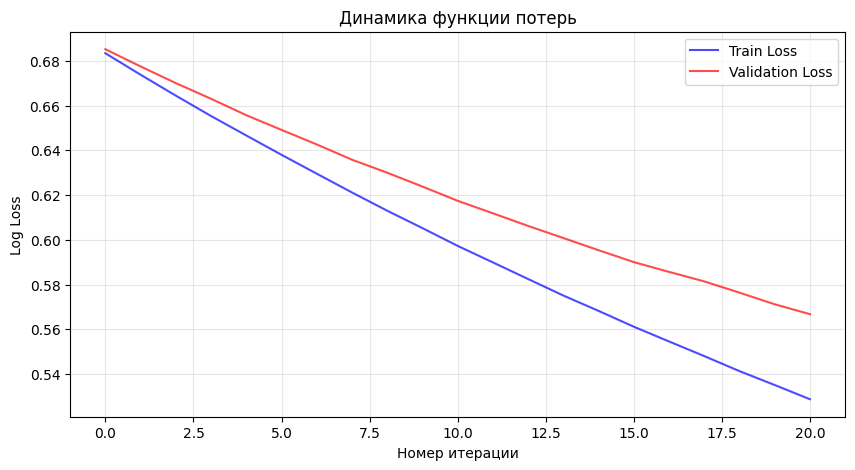

In [ ]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.datasets import make_classification, make_regression
from sklearn.ensemble import GradientBoostingClassifier as SklearnGBM
from sklearn.ensemble import GradientBoostingRegressor as SklearnGBMReg
import matplotlib.pyplot as plt


class MyGradientBoostingClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, n_estimators=100, learning_rate=0.1,
                 max_depth=3, min_samples_split=2, subsample=1.0,
                 random_state=None, verbose=0):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.subsample = subsample
        self.random_state = random_state
        self.verbose = verbose
        self.trees_ = []
        self.initial_prediction_ = None

    @staticmethod
    def sigmoid(x):
        """Сигмоида"""
        return 1 / (1 + np.exp(-x))

    @staticmethod
    def log_loss_gradient(y_true, y_pred):
        return y_true - MyGradientBoostingClassifier.sigmoid(y_pred)

    def fit(self, X, y, X_val=None, y_val=None, early_stopping_rounds=None):
        np.random.seed(self.random_state)
        n_samples = X.shape[0]

        pos_prob = np.mean(y)
        self.initial_prediction_ = np.log(pos_prob / (1 - pos_prob + 1e-10))
        predictions = np.full(n_samples, self.initial_prediction_, dtype=float)

        best_val_score = -np.inf
        best_iteration = 0
        self.best_n_estimators_ = self.n_estimators

        self.trees_ = []
        self.train_loss_ = []
        self.val_loss_ = [] if X_val is not None else None

        for i in range(self.n_estimators):
            if self.subsample < 1.0:
                subsample_size = int(self.subsample * n_samples)
                indices = np.random.choice(n_samples, subsample_size, replace=False)
                X_batch = X[indices]
                y_batch = y[indices]
                pred_batch = predictions[indices]
            else:
                X_batch = X
                y_batch = y
                pred_batch = predictions

            gradient = self.log_loss_gradient(y_batch, pred_batch)

            tree = DecisionTreeRegressor(
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split,
                random_state=self.random_state + i if self.random_state else None
            )
            tree.fit(X_batch, gradient)

            tree_pred = tree.predict(X)
            predictions += self.learning_rate * tree_pred

            self.trees_.append(tree)

            train_probs = self.sigmoid(predictions)
            train_log_loss = -np.mean(y * np.log(train_probs + 1e-10) +
                                    (1 - y) * np.log(1 - train_probs + 1e-10))
            self.train_loss_.append(train_log_loss)

            if X_val is not None and y_val is not None:
                val_probs = self.predict_proba(X_val)[:, 1]
                val_log_loss = -np.mean(y_val * np.log(val_probs + 1e-10) +
                                      (1 - y_val) * np.log(1 - val_probs + 1e-10))

                if self.val_loss_ is not None:
                    self.val_loss_.append(val_log_loss)

                if early_stopping_rounds is not None:
                    if val_log_loss < best_val_score:
                        best_val_score = val_log_loss
                        best_iteration = i
                    elif i - best_iteration >= early_stopping_rounds:
                        self.best_n_estimators_ = best_iteration + 1
                        self.trees_ = self.trees_[:self.best_n_estimators_]
                        if self.verbose:
                            print(f"Early stopping at iteration {i+1}")
                        break

            if self.verbose and i % 10 == 0:
                print(f"Iteration {i+1}/{self.n_estimators}, "
                      f"LogLoss: {train_log_loss:.4f}", end="")
                if X_val is not None and y_val is not None:
                    print(f", LogLoss: {val_log_loss:.4f}", end="")
                print()

        return self

    def predict_proba(self, X):
        """Предсказание вероятностей"""
        predictions = np.full(X.shape[0], self.initial_prediction_, dtype=float)

        for tree in self.trees_:
            predictions += self.learning_rate * tree.predict(X)

        prob_positive = self.sigmoid(predictions)
        return np.column_stack([1 - prob_positive, prob_positive])

    def predict(self, X):
        """Предсказание классов"""
        prob_positive = self.predict_proba(X)[:, 1]
        return (prob_positive >= 0.5).astype(int)

    def staged_predict_proba(self, X):
        """Генератор для последовательного получения вероятностей"""
        predictions = np.full(X.shape[0], self.initial_prediction_, dtype=float)
        for tree in self.trees_:
            predictions += self.learning_rate * tree.predict(X)
            prob_positive = self.sigmoid(predictions)
            yield np.column_stack([1 - prob_positive, prob_positive])

    def get_feature_importances(self):
        if not self.trees_:
            return None

        importances = np.zeros(self.trees_[0].n_features_in_)
        for tree in self.trees_:
            importances += tree.feature_importances_
        return importances / len(self.trees_)

Сравнение (на ненастоящих данных)

a) MyGradientBoostingClassifier:
Accuracy: 0.8900
AUC-ROC: 0.9559
Количество деревьев: 100

b) Sklearn GradientBoostingClassifier:
Accuracy: 0.9083
AUC-ROC: 0.9655

c) XGBoost:
Accuracy: 0.9100
AUC-ROC: 0.9700

d) LightGBM:
   Accuracy: 0.9183
   AUC-ROC: 0.9692

e) CatBoost:


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Accuracy: 0.9200
AUC-ROC: 0.9709

Резы

Модель                | Accuracy  | AUC-ROC   | Отличие от лучшей
-----------------------------------------------------------------
Моё                  | 0.8900    | 0.9559    | Acc: 0.0300, AUC: 0.0150
Sklearn              | 0.9083    | 0.9655    | Acc: 0.0117, AUC: 0.0054
XGBoost              | 0.9100    | 0.9700    | Acc: 0.0100, AUC: 0.0009
LightGBM             | 0.9183    | 0.9692    | Acc: 0.0017, AUC: 0.0017
CatBoost             | 0.9200    | 0.9709    | Acc: 0.0000, AUC: 0.0000

Анализ сходимости
n_estimators= 10: Train Acc=0.9113, Test Acc=0.9350, Train AUC=0.9616, Test AUC=0.9716
n_estimators= 50: Train Acc=0.9287, Test Acc=0.9150, Train AUC=0.9753, Test AUC=0.9799
n_estimators=100: Train Acc=0.9463, Test Acc=0.9400, Train AUC=0.9843, Test AUC=0.9829
n_estimators=200: Train Acc=0.9575, Test Acc=0.9400, Train AUC=0.9921, Test AUC=0.9852
n_estimators=500: Train Acc=0.9825, Test Acc=0.9600, Train AUC=0.9983, Test AUC=0.9859


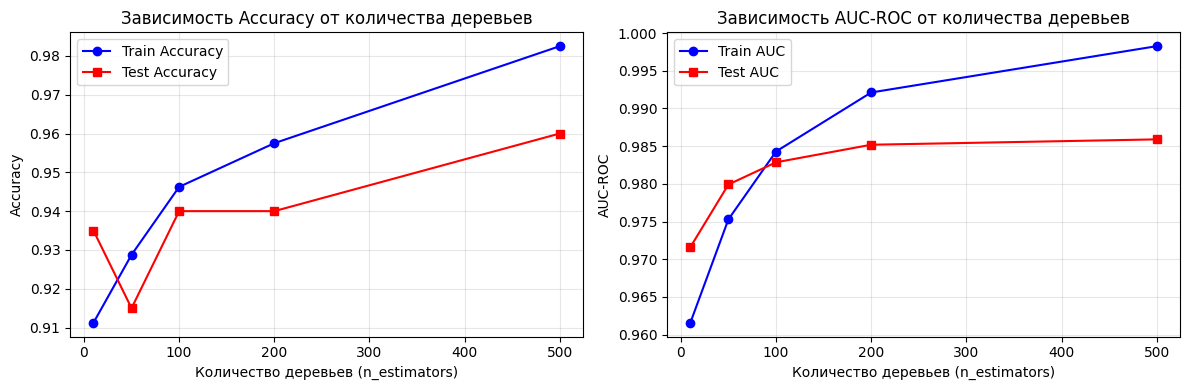

Learning Rate 0.001: Final Test Accuracy = 0.8550
Learning Rate 0.010: Final Test Accuracy = 0.8800
Learning Rate 0.100: Final Test Accuracy = 0.8900
Learning Rate 0.300: Final Test Accuracy = 0.8950
Learning Rate 0.500: Final Test Accuracy = 0.8900
Learning Rate 1.000: Final Test Accuracy = 0.8850


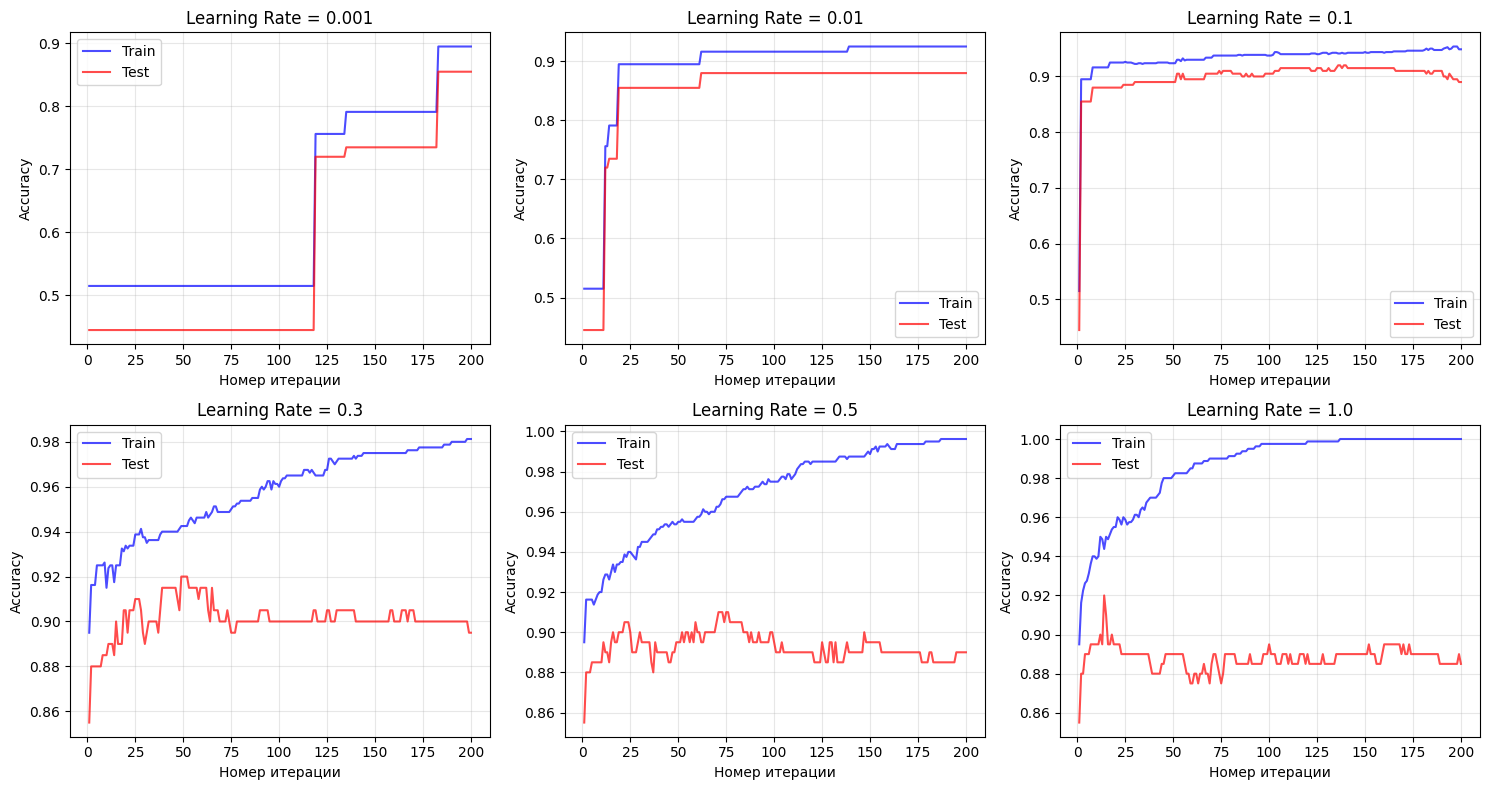

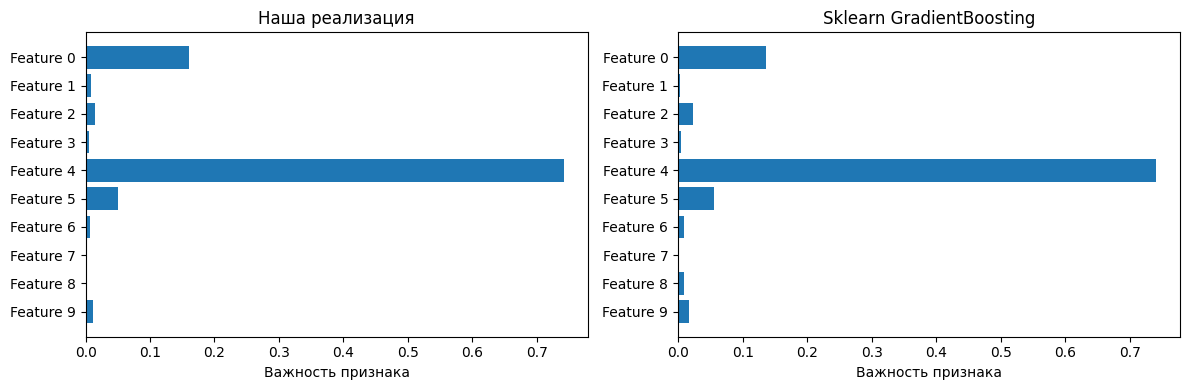


Корреляция важностей признаков между реализациями:
Коэффициент корреляции Пирсона: 0.9992

Топ-3 признака по важности:
Наша реализация:
  1. Feature 4: 0.7417
  2. Feature 0: 0.1611
  3. Feature 5: 0.0500

Sklearn:
  1. Feature 4: 0.7407
  2. Feature 0: 0.1367
  3. Feature 5: 0.0560

Обучение модели с ранней остановкой...
Iteration 1/500, LogLoss: 0.6834, LogLoss: 0.6852
Iteration 11/500, LogLoss: 0.5973, LogLoss: 0.6174
Early stopping at iteration 21

Результаты на тестовой выборке:
Accuracy: 0.8650
AUC-ROC: 0.9215
Использовано деревьев: 1 из 500


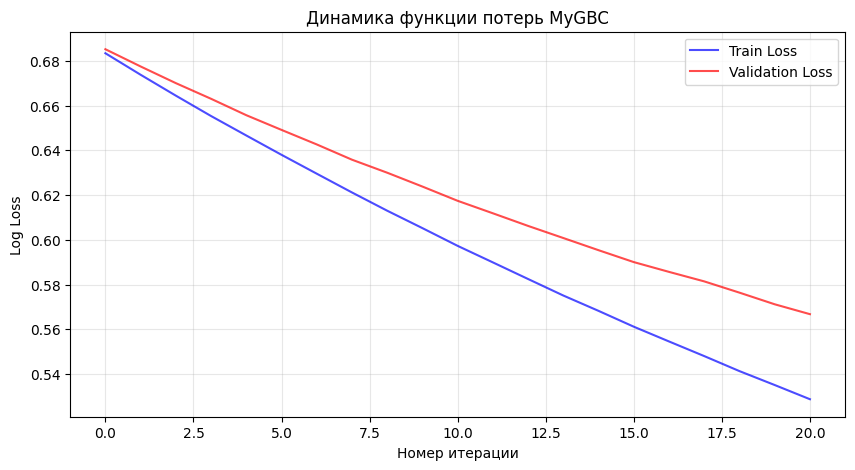


Обучение модели с ранней остановкой...
0:	learn: 0.6490754	total: 11.3ms	remaining: 5.66s
1:	learn: 0.6097163	total: 17.7ms	remaining: 4.41s
2:	learn: 0.5700331	total: 24.2ms	remaining: 4.01s
3:	learn: 0.5337490	total: 30.5ms	remaining: 3.79s
4:	learn: 0.5112345	total: 36.7ms	remaining: 3.63s
5:	learn: 0.4875084	total: 42.6ms	remaining: 3.5s
6:	learn: 0.4630486	total: 48.8ms	remaining: 3.44s
7:	learn: 0.4448198	total: 55ms	remaining: 3.38s
8:	learn: 0.4236351	total: 61.3ms	remaining: 3.34s
9:	learn: 0.4061620	total: 67.6ms	remaining: 3.31s
10:	learn: 0.3923661	total: 73.8ms	remaining: 3.28s
11:	learn: 0.3737350	total: 80.1ms	remaining: 3.26s
12:	learn: 0.3597909	total: 86.5ms	remaining: 3.24s
13:	learn: 0.3452998	total: 92.7ms	remaining: 3.22s
14:	learn: 0.3332234	total: 98.8ms	remaining: 3.19s
15:	learn: 0.3214802	total: 105ms	remaining: 3.18s
16:	learn: 0.3072637	total: 111ms	remaining: 3.17s
17:	learn: 0.2932772	total: 118ms	remaining: 3.15s
18:	learn: 0.2877602	total: 124ms	remain

In [ ]:
def compare_gradient_boosting():

    print("=" * 80)
    print("Сравнение (на ненастоящих данных)")
    print("=" * 80)

    X, y = make_classification(
        n_samples=2000, n_features=20, n_informative=10,
        n_redundant=5, n_classes=2, random_state=42
    )
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42
    )

    print("\na) MyGradientBoostingClassifier:")
    my_gb = MyGradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        subsample=0.8,
        random_state=42,
        verbose=0
    )
    my_gb.fit(X_train, y_train)
    my_pred = my_gb.predict(X_test)
    my_proba = my_gb.predict_proba(X_test)[:, 1]

    my_acc = accuracy_score(y_test, my_pred)
    my_auc = roc_auc_score(y_test, my_proba)

    print(f"Accuracy: {my_acc:.4f}")
    print(f"AUC-ROC: {my_auc:.4f}")
    print(f"Количество деревьев: {len(my_gb.trees_)}")

    # Sklearn
    print("\nb) Sklearn GradientBoostingClassifier:")
    sklearn_gb = SklearnGBM(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        subsample=0.8,
        random_state=42,
        verbose=0
    )
    sklearn_gb.fit(X_train, y_train)
    sklearn_pred = sklearn_gb.predict(X_test)
    sklearn_proba = sklearn_gb.predict_proba(X_test)[:, 1]

    sklearn_acc = accuracy_score(y_test, sklearn_pred)
    sklearn_auc = roc_auc_score(y_test, sklearn_proba)

    print(f"Accuracy: {sklearn_acc:.4f}")
    print(f"AUC-ROC: {sklearn_auc:.4f}")

    # XGBoost
    print("\nc) XGBoost:")
    try:
        import xgboost as xgb
        xgb_clf = xgb.XGBClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=3,
            subsample=0.8,
            random_state=42,
            eval_metric='logloss',
            use_label_encoder=False,
            verbosity=0
        )
        xgb_clf.fit(X_train, y_train)
        xgb_pred = xgb_clf.predict(X_test)
        xgb_proba = xgb_clf.predict_proba(X_test)[:, 1]

        xgb_acc = accuracy_score(y_test, xgb_pred)
        xgb_auc = roc_auc_score(y_test, xgb_proba)

        print(f"Accuracy: {xgb_acc:.4f}")
        print(f"AUC-ROC: {xgb_auc:.4f}")
    except ImportError:
        xgb_acc, xgb_auc = None, None

    # LightGBM
    print("\nd) LightGBM:")
    try:
        import lightgbm as lgb
        lgb_clf = lgb.LGBMClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=3,
            subsample=0.8,
            random_state=42,
            verbose=-1
        )
        lgb_clf.fit(X_train, y_train)
        lgb_pred = lgb_clf.predict(X_test)
        lgb_proba = lgb_clf.predict_proba(X_test)[:, 1]

        lgb_acc = accuracy_score(y_test, lgb_pred)
        lgb_auc = roc_auc_score(y_test, lgb_proba)

        print(f"   Accuracy: {lgb_acc:.4f}")
        print(f"   AUC-ROC: {lgb_auc:.4f}")
    except ImportError:
        lgb_acc, lgb_auc = None, None

    # CatBoost
    print("\ne) CatBoost:")
    try:
        import catboost as cb
        cb_clf = cb.CatBoostClassifier(
            iterations=100,
            learning_rate=0.1,
            depth=3,
            subsample=0.8,
            random_seed=42,
            verbose=False
        )
        cb_clf.fit(X_train, y_train)
        cb_pred = cb_clf.predict(X_test)
        cb_proba = cb_clf.predict_proba(X_test)[:, 1]

        cb_acc = accuracy_score(y_test, cb_pred)
        cb_auc = roc_auc_score(y_test, cb_proba)

        print(f"Accuracy: {cb_acc:.4f}")
        print(f"AUC-ROC: {cb_auc:.4f}")
    except ImportError:
        cb_acc, cb_auc = None, None

    print("\n" + "=" * 80)
    print("Резы")
    print("=" * 80)

    results = {
        'Моё': (my_acc, my_auc),
        'Sklearn': (sklearn_acc, sklearn_auc),
    }

    if xgb_acc is not None:
        results['XGBoost'] = (xgb_acc, xgb_auc)
    if lgb_acc is not None:
        results['LightGBM'] = (lgb_acc, lgb_auc)
    if cb_acc is not None:
        results['CatBoost'] = (cb_acc, cb_auc)

    print("\nМодель                | Accuracy  | AUC-ROC   | Отличие от лучшей")
    print("-" * 65)

    best_acc = max(acc for acc, _ in results.values())
    best_auc = max(auc for _, auc in results.values())

    for model, (acc, auc) in results.items():
        acc_diff = best_acc - acc
        auc_diff = best_auc - auc
        print(f"{model:20} | {acc:.4f}    | {auc:.4f}    | "
              f"Acc: {acc_diff:.4f}, AUC: {auc_diff:.4f}")


def analyze_convergence():

    print("\n" + "=" * 80)
    print("Анализ сходимости")
    print("=" * 80)

    X, y = make_classification(
        n_samples=1000, n_features=10, n_informative=5,
        random_state=42
    )
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    n_estimators_list = [10, 50, 100, 200, 500]

    train_accuracies = []
    test_accuracies = []
    train_aucs = []
    test_aucs = []

    for n_est in n_estimators_list:
        gb = MyGradientBoostingClassifier(
            n_estimators=n_est,
            learning_rate=0.1,
            max_depth=3,
            random_state=42,
            verbose=0
        )
        gb.fit(X_train, y_train)

        train_pred = gb.predict(X_train)
        train_proba = gb.predict_proba(X_train)[:, 1]
        train_acc = accuracy_score(y_train, train_pred)
        train_auc = roc_auc_score(y_train, train_proba)

        test_pred = gb.predict(X_test)
        test_proba = gb.predict_proba(X_test)[:, 1]
        test_acc = accuracy_score(y_test, test_pred)
        test_auc = roc_auc_score(y_test, test_proba)

        train_accuracies.append(train_acc)
        test_accuracies.append(test_acc)
        train_aucs.append(train_auc)
        test_aucs.append(test_auc)

        print(f"n_estimators={n_est:3}: "
              f"Train Acc={train_acc:.4f}, Test Acc={test_acc:.4f}, "
              f"Train AUC={train_auc:.4f}, Test AUC={test_auc:.4f}")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(n_estimators_list, train_accuracies, 'b-', label='Train Accuracy', marker='o')
    axes[0].plot(n_estimators_list, test_accuracies, 'r-', label='Test Accuracy', marker='s')
    axes[0].set_xlabel('Количество деревьев (n_estimators)')
    axes[0].set_ylabel('Accuracy')
    axes[0].set_title('Зависимость Accuracy от количества деревьев')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(n_estimators_list, train_aucs, 'b-', label='Train AUC', marker='o')
    axes[1].plot(n_estimators_list, test_aucs, 'r-', label='Test AUC', marker='s')
    axes[1].set_xlabel('Количество деревьев (n_estimators)')
    axes[1].set_ylabel('AUC-ROC')
    axes[1].set_title('Зависимость AUC-ROC от количества деревьев')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def compare_learning_rates():
    X, y = make_classification(
        n_samples=1000, n_features=10, random_state=42
    )
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    lr_list = [0.001, 0.01, 0.1, 0.3, 0.5, 1.0]

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()

    for idx, lr in enumerate(lr_list):
        gb = MyGradientBoostingClassifier(
            n_estimators=200,
            learning_rate=lr,
            max_depth=3,
            random_state=42,
            verbose=0
        )
        gb.fit(X_train, y_train)

        train_accs = []
        test_accs = []

        for i, proba in enumerate(gb.staged_predict_proba(X_train)):
            pred = (proba[:, 1] >= 0.5).astype(int)
            train_acc = accuracy_score(y_train, pred)
            train_accs.append(train_acc)

        for i, proba in enumerate(gb.staged_predict_proba(X_test)):
            pred = (proba[:, 1] >= 0.5).astype(int)
            test_acc = accuracy_score(y_test, pred)
            test_accs.append(test_acc)

        axes[idx].plot(range(1, 201), train_accs, 'b-', label='Train', alpha=0.7)
        axes[idx].plot(range(1, 201), test_accs, 'r-', label='Test', alpha=0.7)
        axes[idx].set_xlabel('Номер итерации')
        axes[idx].set_ylabel('Accuracy')
        axes[idx].set_title(f'Learning Rate = {lr}')
        axes[idx].legend()
        axes[idx].grid(True, alpha=0.3)

        final_pred = gb.predict(X_test)
        final_acc = accuracy_score(y_test, final_pred)
        print(f"Learning Rate {lr:.3f}: Final Test Accuracy = {final_acc:.4f}")

    plt.tight_layout()
    plt.show()


def feature_importance_comparison():
    X, y = make_classification(
        n_samples=1000,
        n_features=10,
        n_informative=3,
        n_redundant=2,
        random_state=42
    )

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    my_gb = MyGradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42,
        verbose=0
    )
    my_gb.fit(X_train, y_train)
    my_importances = my_gb.get_feature_importances()

    sklearn_gb = SklearnGBM(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42,
        verbose=0
    )
    sklearn_gb.fit(X_train, y_train)
    sklearn_importances = sklearn_gb.feature_importances_

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    features = [f'Feature {i}' for i in range(10)]

    axes[0].barh(features, my_importances)
    axes[0].set_xlabel('Важность признака')
    axes[0].set_title('Наша реализация')
    axes[0].invert_yaxis()

    axes[1].barh(features, sklearn_importances)
    axes[1].set_xlabel('Важность признака')
    axes[1].set_title('Sklearn GradientBoosting')
    axes[1].invert_yaxis()

    plt.tight_layout()
    plt.show()

    print("\nКорреляция важностей признаков между реализациями:")
    correlation = np.corrcoef(my_importances, sklearn_importances)[0, 1]
    print(f"Коэффициент корреляции Пирсона: {correlation:.4f}")

    print("\nТоп-3 признака по важности:")
    print("Наша реализация:")
    top3_my = np.argsort(my_importances)[-3:][::-1]
    for i, idx in enumerate(top3_my, 1):
        print(f"  {i}. Feature {idx}: {my_importances[idx]:.4f}")

    print("\nSklearn:")
    top3_sklearn = np.argsort(sklearn_importances)[-3:][::-1]
    for i, idx in enumerate(top3_sklearn, 1):
        print(f"  {i}. Feature {idx}: {sklearn_importances[idx]:.4f}")

def main():
    compare_gradient_boosting()

    analyze_convergence()

    compare_learning_rates()

    feature_importance_comparison()

    X, y = make_classification(
        n_samples=1000, n_features=20, random_state=42
    )

    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=0.4, random_state=42
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.5, random_state=42
    )

    gb = MyGradientBoostingClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        random_state=42,
        verbose=1
    )

    print("\nОбучение модели с ранней остановкой...")
    gb.fit(X_train, y_train, X_val, y_val, early_stopping_rounds=20)

    y_pred = gb.predict(X_test)
    y_proba = gb.predict_proba(X_test)

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba[:, 1])

    print(f"\nРезультаты на тестовой выборке:")
    print(f"Accuracy: {acc:.4f}")
    print(f"AUC-ROC: {auc:.4f}")
    print(f"Использовано деревьев: {len(gb.trees_)} из 500")

    if hasattr(gb, 'train_loss_') and hasattr(gb, 'val_loss_'):
        plt.figure(figsize=(10, 5))
        plt.plot(gb.train_loss_, 'b-', label='Train Loss', alpha=0.7)
        if gb.val_loss_:
            plt.plot(gb.val_loss_, 'r-', label='Validation Loss', alpha=0.7)
        plt.xlabel('Номер итерации')
        plt.ylabel('Log Loss')
        plt.title('Динамика функции потерь MyGBC')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

    gb = CatBoostClassifier(
        n_estimators=500,
        learning_rate=0.05,
        random_state=42,
        verbose=1
    )

    print("\nОбучение модели с ранней остановкой...")
    gb.fit(X_train, y_train)

    y_pred = gb.predict(X_test)
    y_proba = gb.predict_proba(X_test)

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba[:, 1])

    print(f"\nРезультаты на тестовой выборке:")
    print(f"Accuracy: {acc:.4f}")
    print(f"AUC-ROC: {auc:.4f}")
    print(gb.get_all_params())

main()

Как видно из графиков и по значениям AUC-ROC, лучше всего работает CatBoost (так называемая БАЗА???). Поэтому далее буду использовать его. При этом, как видно, CatBoost не использует деревья явно (там есть деревья, про них и не только лучше почитать [здесь](https://education.yandex.ru/handbook/ml/article/gradientnyj-busting).

![](https://sun9-84.userapi.com/impg/FQ1bHnKu6XgTiULy6qVg_PeO0ECSEBTc-xfPGw/AteIwEvwev4.jpg?size=512x386&quality=96&sign=ae09c21f448ac674a9d2be258e10b96c&type=album)

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

print(X.shape)

print(y.shape)

print(X_test.shape)

gb = MyGradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        subsample=0.8,
        random_state=42,
        verbose=1
    )

In [ ]:
from catboost import CatBoostClassifier

gb = CatBoostClassifier(
    iterations=200,
    learning_rate=0.15
)

In [ ]:
from sklearn.metrics import classification_report

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

gb.fit(X_train, y_train)

y_val_pred = gb.predict(X_val)
y_val_proba = gb.predict_proba(X_val)[:, 1]

y_test_pred = gb.predict(X_test)
y_test_proba = gb.predict_proba(X_test)[:, 1]

auc_score = roc_auc_score(y_val, y_val_proba)
print(f"ROC AUC Score: {auc_score:.4f}")

print("\nClassification Report for Validation Set:")
print(classification_report(y_val, y_val_pred))

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print(f"\nAccuracy: {accuracy_score(y_val, y_val_pred):.4f}")
print(f"Precision: {precision_score(y_val, y_val_pred):.4f}")
print(f"Recall: {recall_score(y_val, y_val_pred):.4f}")
print(f"F1-Score: {f1_score(y_val, y_val_pred):.4f}")

In [ ]:
gb.fit(X, y)
y_pred = gb.predict(X_test)

submission_df = pd.DataFrame({
    'ID': test_ids,
    'LoanApproved': y_pred
})
submission_df.to_csv('submission_kitty.csv', index=False)

print(submission_df.head())

In [ ]:
!pip install optuna optuna-integration[catboost]


In [ ]:
import optuna
from optuna.integration import CatBoostPruningCallback
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.model_selection import train_test_split

categorical_features = []
for col in X.columns:
    if X[col].dtype == 'object' or X[col].nunique() < 20:
        categorical_features.append(col)
        X[col] = X[col].astype(str).fillna('missing')
        if X_test is not None and col in X_test.columns:
            X_test[col] = X_test[col].astype(str).fillna('missing')

cat_features_indices = [i for i, col in enumerate(X.columns) if col in categorical_features]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

def objective(trial: optuna.Trial) -> float:
    param = {
        "objective": trial.suggest_categorical("objective", ["Logloss", "CrossEntropy"]),
        "colsample_bylevel": trial.suggest_float("colsample_bylevel", 0.01, 1.0),
        "depth": trial.suggest_int("depth", 4, 12),
        "learning_rate": trial.suggest_float("learning_rate", 0.001, 0.3, log=True),
        "iterations": trial.suggest_int("iterations", 100, 2000),

        "boosting_type": trial.suggest_categorical("boosting_type", ["Ordered", "Plain"]),
        "bootstrap_type": trial.suggest_categorical(
            "bootstrap_type", ["Bayesian", "Bernoulli", "MVS"]
        ),

        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1e-8, 100.0, log=True),
        "random_strength": trial.suggest_float("random_strength", 1e-8, 10.0, log=True),

        "border_count": trial.suggest_int("border_count", 32, 255),
        "random_seed": 42,
        "verbose": False,
        "cat_features": cat_features_indices,
        "eval_metric": "AUC",
    }

    if param["bootstrap_type"] == "Bayesian":
        param["bagging_temperature"] = trial.suggest_float("bagging_temperature", 0, 10)
    elif param["bootstrap_type"] == "Bernoulli":
        param["subsample"] = trial.suggest_float("subsample", 0.1, 1.0)

    param["od_type"] = trial.suggest_categorical("od_type", ["IncToDec", "Iter"])
    param["od_wait"] = trial.suggest_int("od_wait", 10, 100)

    gbm = CatBoostClassifier(**param)

    pruning_callback = CatBoostPruningCallback(trial, "AUC")

    try:
        gbm.fit(
            X_train,
            y_train,
            eval_set=[(X_val, y_val)],
            verbose=0,
            early_stopping_rounds=param["od_wait"],
            callbacks=[pruning_callback],
        )

        pruning_callback.check_pruned()

        preds = gbm.predict_proba(X_val)[:, 1]

        auc = roc_auc_score(y_val, preds)

        return auc

    except Exception as e:
        return 0.0

print("\n" + "="*80)
print("ОПТУНИЗАЦИЯ!!!!!!!!!!")
print("="*80)

study = optuna.create_study(
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=10),
    direction="maximize",
    study_name="catboost_official_style"
)

try:
    study.optimize(objective, n_trials=50, timeout=3600, show_progress_bar=True)
except KeyboardInterrupt:
    print("Optimization interrupted by user")

print("\n" + "="*80)
print("OPTIMIZATION RESULTS")
print("="*80)
print(f"Number of finished trials: {len(study.trials)}")
print(f"Best trial: {study.best_trial.number}")
print(f"Best ROC AUC: {study.best_trial.value:.4f}")

print("\nBest parameters:")
for key, value in study.best_params.items():
    print(f"{key}: {value}")

print("\n" + "="*80)
print("Тренинг финальной модели")
print("="*80)

best_params = study.best_params.copy()

best_params.update({
    "random_seed": 42,
    "verbose": True,
    "cat_features": cat_features_indices,
    "eval_metric": "AUC",
})


final_model = CatBoostClassifier(**best_params)

final_model.fit(
    X, y,
    eval_set=[(X_val, y_val)],
    verbose=100
)


y_val_pred = final_model.predict(X_val)
y_val_proba = final_model.predict_proba(X_val)[:, 1]

print(f"ROC AUC: {roc_auc_score(y_val, y_val_proba):.4f}")
print(f"Accuracy: {accuracy_score(y_val, y_val_pred):.4f}")

In [ ]:
print("\n" + "="*80)
print("Трен полностью для Кагла")
print("="*80)

best_params["iterations"] = final_model.get_best_iteration() + 100 if hasattr(final_model, 'get_best_iteration') else 1000

full_model = CatBoostClassifier(**best_params)
full_model.fit(X, y, verbose=100)

y_pred = full_model.predict(X_test)
y_pred_proba = full_model.predict_proba(X_test)[:, 1]

submission_df = pd.DataFrame({
    'ID': test_ids,
    'LoanApproved': y_pred
})
submission_df.to_csv('submission_kitty_best.csv', index=False)
print(submission_df.head())

submission_proba_df = pd.DataFrame({
    'ID': test_ids,
    'LoanApproved': y_pred_proba
})
submission_proba_df.to_csv('submission_kitty_best_proba_official.csv', index=False)
print(f"\n'submission_kitty_best_proba_official.csv'")

full_model.save_model('kitty_official_model.cbm')
print(f"\nsaved: 'kitty_official_model.cbm'")

## Всякие метрики

In [ ]:
def precision(y_true, y_pred):
    """Precision = TP / (TP + FP)"""
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    tp = np.sum((y_true == 1) & (y_pred == 1))
    fp = np.sum((y_true == 0) & (y_pred == 1))

    return tp / (tp + fp) if (tp + fp) > 0 else 0.0

In [ ]:
def recall(y_true, y_pred):
    """Recall = TP / (TP + FN)"""
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    tp = np.sum((y_true == 1) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))

    return tp / (tp + fn) if (tp + fn) > 0 else 0.0

In [ ]:
def f1_score(y_true, y_pred):
    """F1 = 2 * (precision * recall) / (precision + recall)"""
    p = precision(y_true, y_pred)
    r = recall(y_true, y_pred)

    return 2 * p * r / (p + r) if (p + r) > 0 else 0.0

In [ ]:
def confusion_matrix_metrics(y_true, y_pred):
    """Вычисляет TP, FP, TN, FN"""
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    tp = np.sum((y_true == 1) & (y_pred == 1))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fn = np.sum((y_true == 1) & (y_pred == 0))

    return tp, fp, tn, fn

def roc_auc(y_true, y_score):
    """AUC-ROC через TP, FP, TN, FN """
    y_true = np.array(y_true)
    y_score = np.array(y_score)

    thresholds = np.sort(np.unique(y_score))[::-1]

    thresholds = np.append(thresholds, thresholds[-1] - 0.1)
    thresholds = np.append(1.1, thresholds)

    tpr_list = []
    fpr_list = []

    for threshold in thresholds:
        y_pred = (y_score >= threshold).astype(int)
        tp, fp, tn, fn = confusion_matrix_metrics(y_true, y_pred)
        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0

        tpr_list.append(tpr)
        fpr_list.append(fpr)

    sorted_indices = np.argsort(fpr_list)
    fpr_sorted = np.array(fpr_list)[sorted_indices]
    tpr_sorted = np.array(tpr_list)[sorted_indices]

    auc = 0.0
    for i in range(1, len(fpr_sorted)):
        auc += (fpr_sorted[i] - fpr_sorted[i-1]) * (tpr_sorted[i] + tpr_sorted[i-1]) / 2

    return auc

def pr_auc(y_true, y_score):
    """AUC-PR через TP, FP, FN"""
    y_true = np.array(y_true)
    y_score = np.array(y_score)

    thresholds = np.sort(np.unique(y_score))[::-1]

    thresholds = np.append(thresholds, thresholds[-1] - 0.1)
    thresholds = np.append(1.1, thresholds)

    precision_list = []
    recall_list = []

    for threshold in thresholds:
        y_pred = (y_score >= threshold).astype(int)
        tp, fp, _, fn = confusion_matrix_metrics(y_true, y_pred)
        p = tp / (tp + fp) if (tp + fp) > 0 else 1.0
        r = tp / (tp + fn) if (tp + fn) > 0 else 0.0

        precision_list.append(p)
        recall_list.append(r)
    sorted_indices = np.argsort(recall_list)
    recall_sorted = np.array(recall_list)[sorted_indices]
    precision_sorted = np.array(precision_list)[sorted_indices]

    recall_sorted = np.concatenate([[0], recall_sorted])
    precision_sorted = np.concatenate([[1], precision_sorted])

    auc = 0.0
    for i in range(1, len(recall_sorted)):
        auc += (recall_sorted[i] - recall_sorted[i-1]) * (precision_sorted[i] + precision_sorted[i-1]) / 2

    return auc

In [ ]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier
from sklearn.metrics import precision_score, recall_score, f1_score as sk_f1
from sklearn.metrics import roc_auc_score, average_precision_score

if __name__ == "__main__":
    X, y = make_classification(
        n_samples=2000,
        n_features=42,
        n_informative=10,
        n_redundant=5,
        n_classes=2,
        random_state=42,
        weights=[0.7, 0.3]
    )

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42
    )

    print(f"Сгенерировано данных: {X.shape[0]} примеров, {X.shape[1]} признаков")
    print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")
    print(f"Баланс классов в тесте: {np.mean(y_test == 1):.3f} положительных")

    gb = CatBoostClassifier(
        iterations=200,
        learning_rate=0.15,
        random_seed=42,
        verbose=0
    )

    gb.fit(X_train, y_train)

    y_pred = gb.predict(X_test)
    y_score = gb.predict_proba(X_test)[:, 1]

    print("\nРезультаты:")
    print("-" * 80)
    print(f"precision: {precision(y_test, y_pred):.4f} (sklearn: {precision_score(y_test, y_pred):.4f})")
    print(f"recall: {recall(y_test, y_pred):.4f} (sklearn: {recall_score(y_test, y_pred):.4f})")
    print(f"f1_score: {f1_score(y_test, y_pred):.4f} (sklearn: {sk_f1(y_test, y_pred):.4f})")
    print(f"roc_auc: {roc_auc(y_test, y_score):.4f} (sklearn: {roc_auc_score(y_test, y_score):.4f})")
    print(f"pr_auc: {pr_auc(y_test, y_score):.4f} (sklearn: {average_precision_score(y_test, y_score):.4f})")

    print("=" * 80)

    metrics_diff = {
        'precision': abs(precision(y_test, y_pred) - precision_score(y_test, y_pred)),
        'recall': abs(recall(y_test, y_pred) - recall_score(y_test, y_pred)),
        'f1_score': abs(f1_score(y_test, y_pred) - sk_f1(y_test, y_pred)),
        'roc_auc': abs(roc_auc(y_test, y_score) - roc_auc_score(y_test, y_score)),
        'pr_auc': abs(pr_auc(y_test, y_score) - average_precision_score(y_test, y_score))
    }

    for metric_name, diff in metrics_diff.items():
        print(f"{metric_name}: {diff:.10f}")


Сгенерировано данных: 2000 примеров, 42 признаков
Train: 1400, Test: 600
Баланс классов в тесте: 0.295 положительных

Результаты:
--------------------------------------------------------------------------------
precision: 0.8757 (sklearn: 0.8757)
recall: 0.8362 (sklearn: 0.8362)
f1_score: 0.8555 (sklearn: 0.8555)
roc_auc: 0.9729 (sklearn: 0.9731)
pr_auc: 0.9376 (sklearn: 0.9384)
precision: 0.0000000000
recall: 0.0000000000
f1_score: 0.0000000000
roc_auc: 0.0002003446
pr_auc: 0.0007984810


![](https://files.codingninjas.in/article_images/catboost-ml-0-1646121377.webp)